# Pseudobulk transcriptomics of CD19 CAR T-cell infusion products

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/martingarridorc/SysBio-ACSB-2026/blob/main/CAR_T_pseudobulk_analysis.ipynb)

**Dataset:** Single cell RNA-seq of CD19 CAR T-cell infusion products ([Deng et al., Nat Med 2020](https://doi.org/10.1038/s41591-020-1061-7)), 133,405 cells from 24 patients, distributed via CZ CELLxGENE.

**Contrast of interest:** within the **non-exhausted** T-cell compartment, we ask how CAR transduction (**CAR+** vs **CAR-**) affects specific cell types &mdash; concretely, **Cycling CD4** and **Cycling CD8** &mdash; each modeled separately, then drill into **Cycling CD8** for functional and cell-cell-communication follow-up.

**Workflow:**
1. Load precomputed pseudobulk profiles and visualize the full pseudobulk landscape (UMAP), tagging the case/control groups.
2. QC and filter the pseudobulk profiles.
3. Differential expression with `pydeseq2`, fit separately within Cycling CD4 and within Cycling CD8, then compared to each other.
4. Functional interpretation of the Cycling CD8 CAR effect with `decoupler` (ORA on MSigDB Hallmarks, GSEA on PROGENy, TF activity via CollecTRI / `omnipath`).
5. Cell-cell communication with `liana+` to see how *other* cell types' ligand-receptor interactions with Cycling CD8 are gained/lost once it becomes CAR-transduced.

All analysis runs in the `sysbio` conda environment.


## T-cell states in this dataset: a brief primer

This dataset's `cell_type_in_paper` labels (Cycling CD4, Cycling CD8, Naive CD8, Memory CD4, Exhausted CD8, TH17, Treg, ...) and its separate `exhaustion_status` field both describe T-cell *state*, as distinct from T-cell *lineage* (CD4 helper vs. CD8 cytotoxic, Treg, TH17, etc.). The three states this notebook works with most directly are:

- **Non-cycling (quiescent) T cells** &mdash; the resting baseline. Naive T cells (never encountered their cognate antigen) and most memory T cells (previously activated, now at rest but poised for rapid recall) sit in G0 of the cell cycle: low biosynthetic/ribosomal activity, no cell-cycle gene expression. This is the default state most T cells in an infusion product are in at any given moment.

- **Cycling (proliferating) T cells** &mdash; cells actively progressing through the cell cycle (S/G2/M), identifiable by proliferation genes (e.g. *MKI67*, *TOP2A*, and cell-cycle machinery generally). Antigen recognition is the normal trigger for a T cell to exit quiescence and clonally expand; a burst of proliferation is the hallmark of a productive, recently activated T-cell response. This is directly relevant here because CAR engagement is expected to act as exactly this kind of activating trigger &mdash; which is part of why this notebook's CAR+ vs CAR- contrasts keep surfacing proliferation programs (E2F/MYC target genes) as part of the CAR-associated signature.

- **Exhausted T cells** &mdash; a distinct, dysfunctional differentiation state driven by prolonged or repeated antigen stimulation (chronic infection, tumors, or persistent CAR engagement). Exhausted cells progressively lose effector function (cytotoxicity, cytokine production) while upregulating inhibitory receptors (PD-1/*PDCD1*, TIM-3/*HAVCR2*, LAG3, TIGIT, CTLA4) and adopting a *TOX*-driven epigenetic program that becomes increasingly fixed over time. Exhaustion is a major clinical limitation of CAR T-cell therapy &mdash; exhausted CAR T cells lose anti-tumor potency and persistence &mdash; which is exactly why this notebook holds exhaustion status fixed (non-exhausted only) for its CAR+/CAR- contrasts, rather than letting exhaustion-driven differences confound the CAR effect.

**Why "Cycling" and "Exhausted" can overlap:** proliferation and exhaustion are not mutually exclusive states &mdash; a chronically stimulated T cell can still be cycling while also carrying exhaustion markers, particularly early in the exhaustion program. That is presumably why this dataset's authors track them as two separate variables: a discrete cluster identity (`cell_type_in_paper`, assigned from the dominant transcriptional signature of each cluster) and a separate, independently derived `exhaustion_status` call, rather than one mutually exclusive label. Concretely, in the non-exhausted slice of `pb_full` used throughout this notebook, a number of pseudobulk samples are still clustered as `cell_type_in_paper == "Exhausted CD8"` despite carrying a `non_exhausted` `exhaustion_status` call &mdash; a reminder that these two annotations capture related but distinct aspects of T-cell state.

## How the pseudobulk profiles were built (read this first)

**You will not have access to the original single-cell file in this notebook** &mdash; we start directly from a precomputed pseudobulk file, `pb_full.h5ad`. This section explains what that means and why.

Single-cell RNA-seq counts are sparse and noisy, and a dataset's thousands of cells from the same patient are *not* independent biological replicates &mdash; feeding them directly into a bulk differential-expression tool like DESeq2 would massively overstate statistical confidence (a classic "pseudoreplication" error). The standard fix is **pseudobulking**: sum the raw UMI counts of all cells that share the same combination of biological labels of interest, producing one aggregated "sample" per combination. The result looks just like an ordinary bulk RNA-seq count table (one row of gene counts per sample), but each row still carries information about which patient, cell type, and condition it came from.

For this dataset, single cells were grouped by **donor x cell type x CAR status x exhaustion status**, and raw counts were summed within every group containing at least 10 cells:

- **`donor_id`** &mdash; the true biological replicate unit (one CAR T-cell infusion product per patient). Including it in the DESeq2 design controls for inter-patient variability before testing the CAR effect.
- **`cell_type_in_paper`** &mdash; the authors' cell-type annotation. Pooling cell types together before aggregating (i.e. summing raw counts across cell types within a donor) would confound any CAR+/CAR- signal with shifts in cell-type composition between samples, so it is kept as its own grouping level here. This also means `pb_full` is already at the right granularity to ask the CAR question separately *within* any single cell type, which is exactly what Section 3 does.
- **`CAR`** (CAR+ / CAR-) &mdash; the transduction status, and our condition of interest: CAR+ cells carry the engineered CAR transgene ("transformed"), CAR- cells do not ("non-transformed").
- **`exhaustion_status`** &mdash; exhaustion is a major, largely independent source of transcriptional variation in T cells. We hold it fixed (non-exhausted only) for the primary contrast so it does not get entangled with the CAR effect.

This aggregation was performed once, offline, by [`build_pseudobulk.py`](build_pseudobulk.py) in this repository, which: (1) downloads the ~1.6 GB raw single-cell `.h5ad` file from [CZ CELLxGENE Discover](https://datasets.cellxgene.cziscience.com/25735b46-c216-43fb-8cae-5b890090b714.h5ad) if it is not already present, (2) sums raw counts within every donor x cell type x CAR x exhaustion group (>=10 cells), and (3) writes the result to `pb_full.h5ad` (738 samples x 19,522 genes). **The raw single-cell file itself is about 35x larger than the pseudobulk file and is not needed once this aggregation is done** &mdash; which is exactly why this notebook loads `pb_full.h5ad` directly instead.

For the DESeq2 contrast we work directly with the non-exhausted slice of `pb_full` &mdash; one row per **donor x cell type x CAR** &mdash; rather than collapsing it further. Summing across cell types into a single donor x CAR sample would mix the CAR effect with any difference in cell-type composition between a donor's CAR+ and CAR- pools, and a model that pools the CAR effect *across* cell types would only tell us about a shared, average effect rather than how a specific cell type responds. Section 1 below builds `pb_bulk` at the donor x cell type x CAR granularity, and Section 3 subsets it into one cell type at a time (Cycling CD4, Cycling CD8) and fits a separate `~donor_id + CAR` model within each.


## Environment setup (Colab-friendly)

### Opening this notebook in Google Colab

**Quickest way:** click the "Open In Colab" badge at the very top of this notebook, or follow this link directly:
`https://colab.research.google.com/github/martingarridorc/SysBio-ACSB-2026/blob/main/CAR_T_pseudobulk_analysis.ipynb`

**Manually, via Colab's "Open from GitHub" option:**
1. Go to [colab.research.google.com](https://colab.research.google.com/).
2. In the **File** menu, choose **Open notebook** (this dialog also appears automatically when Colab first loads).
3. Select the **GitHub** tab.
4. Paste the repository URL `https://github.com/martingarridorc/SysBio-ACSB-2026` into the search box and press Enter.
5. Pick `CAR_T_pseudobulk_analysis.ipynb` from the list of notebooks found in the repository.

Either route opens a live copy running on Google's infrastructure -- no local Python install needed. From there, running the next cell will:

1. **Install any missing Python packages** (`scanpy`, `anndata`, `pydeseq2`, `decoupler`, `omnipath`, `liana`, `plotnine`, `adjustText`, `seaborn`, `gdown`) — skipped automatically if they are already present (e.g. in the `sysbio` conda environment).
2. **Download one small precomputed pseudobulk file** (`pb_full.h5ad`, ~46 MB) from Google Drive if it is not already sitting in the working directory.

We start from a precomputed pseudobulk profile rather than the original ~1.6 GB single-cell object because the latter is too heavy for a free Colab runtime (see the section just above for what pseudobulking means and how this file was built).

**Before running this notebook on Colab**, upload `pb_full.h5ad` to your Google Drive, set sharing to "Anyone with the link", and paste its file ID into `PB_FULL_DRIVE_ID` in the next code cell (the ID is the long string in the share link: `https://drive.google.com/file/d/<ID>/view`).

You can just run the whole notebook top-to-bottom, on a local environment or on a fresh Google Colab runtime.

In [1]:
import importlib
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules

# (import name -> pip spec). Versions are pinned for the packages whose APIs
# changed across recent releases (decoupler v2, liana, pydeseq2, plotnine).
REQUIRED_PACKAGES = {
    "scanpy": "scanpy>=1.10",
    "anndata": "anndata>=0.10",
    "pydeseq2": "pydeseq2==0.5.4",
    "decoupler": "decoupler==2.1.6",
    "omnipath": "omnipath==1.0.12",
    "liana": "liana==1.7.3",
    "plotnine": "plotnine==0.15.7",
    "adjustText": "adjustText==1.4.0",
    "seaborn": "seaborn>=0.13",
    "gdown": "gdown",
}

missing_specs = []
for module_name, pip_spec in REQUIRED_PACKAGES.items():
    try:
        importlib.import_module(module_name)
    except ImportError:
        missing_specs.append(pip_spec)

if missing_specs:
    print(f"Installing {len(missing_specs)} missing package(s): {', '.join(missing_specs)}")
    print("(first run only - this can take a few minutes, e.g. on a fresh Colab runtime)")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *missing_specs],
        check=True,
    )
    print("Done installing packages.")
else:
    print("All required packages are already installed.")


All required packages are already installed.


## 0. Setup: imports, style, and consistent color palettes


In [2]:
import warnings
warnings.filterwarnings("ignore")

import os

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from adjustText import adjust_text
import requests

import decoupler as dc
import liana as li
import plotnine as p9
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

sc.settings.verbosity = 1
plt.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 130,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

H5AD_IN = "25735b46-c216-43fb-8cae-5b890090b714.h5ad"

# Colors used consistently across every figure in this notebook
CAR_PALETTE = {"CAR+": "#D62728", "CAR-": "#1F77B4"}
GROUP_PALETTE = {
    "case_CARpos_nonexhausted": "#D62728",
    "control_CARneg_nonexhausted": "#1F77B4",
    "other_exhausted": "#BBBBBB",
}
GROUP_LABELS = {
    "case_CARpos_nonexhausted": "Case: CAR+ / non-exhausted",
    "control_CARneg_nonexhausted": "Control: CAR- / non-exhausted",
    "other_exhausted": "Other (exhausted, either CAR status)",
}


## 1. Load precomputed pseudobulk profiles

We load a single pseudobulk object, **`pb_full`**, built ahead of time from the raw integer counts (`adata.raw.X`) of the original 133,405-cell single-cell dataset by summing cells within each donor x cell type x CAR status x exhaustion status group (groups with >=10 cells; see `build_pseudobulk.py`). This is the object used for the UMAP overview and the LIANA+ analysis.

For the case/control DESeq2 contrast we need **`pb_bulk`**: the non-exhausted slice of `pb_full`, i.e. donor x cell type x CAR, restricted to cell types with enough samples to be usable. We deliberately do **not** collapse this further to donor x CAR by summing across cell types &mdash; that would mix the CAR effect with any difference in cell-type composition between the CAR+ and CAR- pools of a given donor, and would also prevent us from asking the question this notebook is actually about: how does CAR transduction affect a *specific* cell type. `cell_type_in_paper` stays as its own column so Section 3 can subset `pb_bulk` to one cell type at a time.

We also drop two non-T-cell clusters (`Myeloid like`, `IACs`) that appear in this infusion-product dataset alongside the T cells &mdash; the CAR+/CAR- contrast here is specifically about the T-cell compartment. We additionally require >=10 pseudobulk samples for a cell type to be kept at all, for the same reason `build_pseudobulk.py` required >=10 cells per group: too few samples makes any per-cell-type effect estimate unstable.

In [3]:
# --- Fill this in after uploading pb_full.h5ad to Google Drive ---
# Right-click the file in Drive -> Share -> "Anyone with the link" -> Copy link.
# The link looks like: https://drive.google.com/file/d/<FILE_ID>/view?usp=sharing
# Paste just the <FILE_ID> portion below.
PB_FULL_DRIVE_ID = "10l2i1ZGPI7XDQPrccUm4GM9RMYfQSzc1"

PB_FULL_PATH = "pb_full.h5ad"


def fetch_from_drive(local_path, drive_id):
    if os.path.exists(local_path):
        print(f"Found existing local file: {local_path}")
        return
    if not drive_id or drive_id.startswith("REPLACE_WITH"):
        raise FileNotFoundError(
            f"{local_path} not found locally and no Google Drive file ID was provided. "
            f"Upload it to Google Drive, share it as \"Anyone with the link\", and set its ID above."
        )
    print(f"Downloading {local_path} from Google Drive (id={drive_id})...")
    gdown.download(id=drive_id, output=local_path, quiet=False)


import gdown

fetch_from_drive(PB_FULL_PATH, PB_FULL_DRIVE_ID)

pb_full = ad.read_h5ad(PB_FULL_PATH)
print("pb_full:", pb_full.shape)
print(pb_full.obs["group_tag"].value_counts())

# pb_bulk: non-exhausted slice of pb_full, kept at donor x cell_type x CAR
# granularity (no summing across cell types -> no composition confound).
NON_T_CELL_TYPES = {"Myeloid like", "IACs"}
MIN_SAMPLES_PER_CELLTYPE = 10

nonexh = pb_full[pb_full.obs["exhaustion_status"] == "non_exhausted"]
ct_counts = nonexh.obs["cell_type_in_paper"].value_counts()
keep_cts = [
    ct for ct in ct_counts.index
    if ct not in NON_T_CELL_TYPES and ct_counts[ct] >= MIN_SAMPLES_PER_CELLTYPE
]
print(f"\nCell types dropped (non-T or <{MIN_SAMPLES_PER_CELLTYPE} samples):",
      sorted(set(ct_counts.index) - set(keep_cts)))
print("Cell types kept:", sorted(keep_cts))

pb_bulk = nonexh[nonexh.obs["cell_type_in_paper"].isin(keep_cts)].copy()
pb_bulk.X = np.asarray(pb_bulk.X.todense())  # pb_full.X is sparse; DESeq2 needs a dense count matrix
pb_bulk.obs["donor_id"] = pb_bulk.obs["donor_id"].astype(str).astype("category")
pb_bulk.obs["cell_type_in_paper"] = pb_bulk.obs["cell_type_in_paper"].astype(str).astype("category")
pb_bulk.obs["CAR"] = pb_bulk.obs["CAR"].astype(str).astype("category")
pb_bulk.layers["counts"] = pb_bulk.X.copy()

print("\npb_bulk:", pb_bulk.shape)
print(pb_bulk.obs.groupby("CAR").size())
print("\nSamples per cell type x CAR:")
print(pb_bulk.obs.groupby(["cell_type_in_paper", "CAR"], observed=True).size().unstack(fill_value=0))
print("\nDonors represented:", pb_bulk.obs["donor_id"].nunique())


Found existing local file: pb_full.h5ad


pb_full: (738, 19522)
group_tag
other_exhausted                401
control_CARneg_nonexhausted    204
case_CARpos_nonexhausted       133
Name: count, dtype: int64

Cell types dropped (non-T or <10 samples): ['Activated CD4', 'CD4', 'Effectory memory CD8', 'IACs', 'Myeloid like', 'Teff CD8 (activated )']
Cell types kept: ['CD8', 'CD8-LAMP3-high', 'Cycling CD4', 'Cycling CD8', 'Exhausted CD8', 'Memory CD4', 'Naive CD8', 'TH17', 'Treg']

pb_bulk: (302, 19522)
CAR
CAR+    125
CAR-    177
dtype: int64

Samples per cell type x CAR:
CAR                 CAR+  CAR-
cell_type_in_paper            
CD8                   11    18
CD8-LAMP3-high         1    19
Cycling CD4           21    21
Cycling CD8           19    23
Exhausted CD8         16    21
Memory CD4            21    22
Naive CD8              9    17
TH17                  19    20
Treg                   8    16

Donors represented: 24


## 1b. UMAP overview of the pseudobulk landscape

We visualize all `pb_full` pseudobulk profiles (every donor x cell-type x CAR x exhaustion combination that passed the cell-count threshold), and look at the same embedding from three angles: which profiles are our case/control samples, which patient they come from, and which cell type they represent.


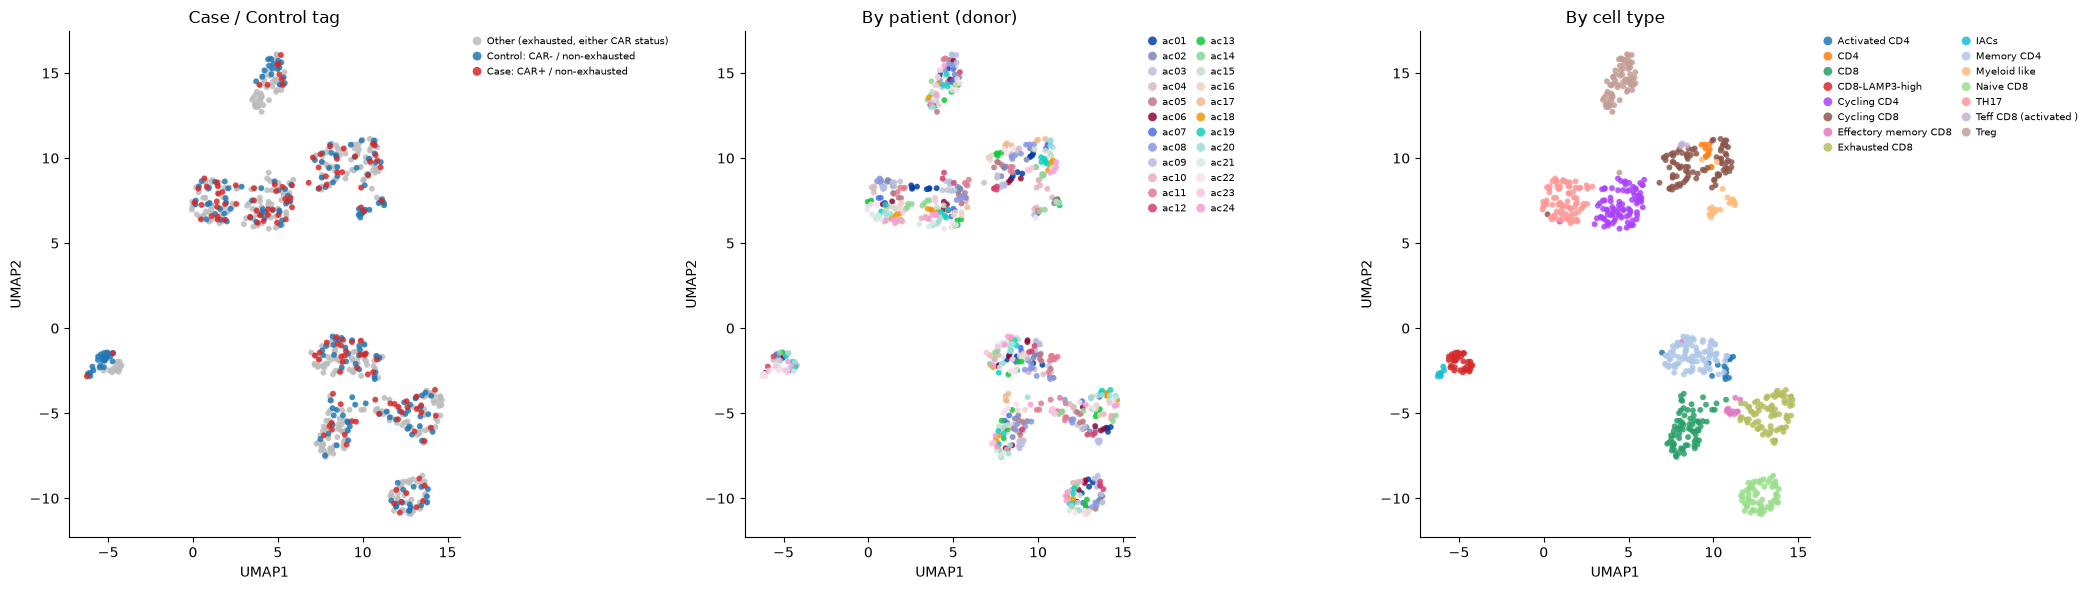

In [4]:
pb_vis = pb_full.copy()
sc.pp.normalize_total(pb_vis, target_sum=1e6)
sc.pp.log1p(pb_vis)
sc.pp.highly_variable_genes(pb_vis, n_top_genes=2000)
sc.pp.scale(pb_vis, max_value=10)
sc.tl.pca(pb_vis, n_comps=20, use_highly_variable=True)
sc.pp.neighbors(pb_vis, n_neighbors=15)
sc.tl.umap(pb_vis, random_state=0)

donors = sorted(pb_vis.obs["donor_id"].unique())
cell_types = sorted(pb_vis.obs["cell_type_in_paper"].unique())
donor_palette = dict(zip(donors, sc.pl.palettes.default_28[:len(donors)]))
celltype_palette = dict(zip(cell_types, sc.pl.palettes.default_20[:len(cell_types)]))

um = pb_vis.obsm["X_umap"]
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

group_order = ["other_exhausted", "control_CARneg_nonexhausted", "case_CARpos_nonexhausted"]
for ax, col, pal, order, title in [
    (axes[0], "group_tag", GROUP_PALETTE, group_order, "Case / Control tag"),
    (axes[1], "donor_id", donor_palette, donors, "By patient (donor)"),
    (axes[2], "cell_type_in_paper", celltype_palette, cell_types, "By cell type"),
]:
    for cat in order:
        m = (pb_vis.obs[col] == cat).values
        label = GROUP_LABELS.get(cat, cat) if col == "group_tag" else cat
        ax.scatter(um[m, 0], um[m, 1], s=18, c=[pal[cat]], label=label, alpha=0.85, edgecolors="none")
    ax.set_title(title)
    ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
    ncol = 1 if len(pal) <= 12 else 2
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=7, ncol=ncol, markerscale=1.5)

plt.tight_layout()
plt.show()


**Reading the panels:** profiles cluster primarily by **cell type** (right panel) &mdash; the dominant axis of variation in the pseudobulk transcriptome is cell identity, not CAR/exhaustion status. The case (CAR+, red) and control (CAR-, blue) tags are scattered *within* each cell-type cluster, confirming that the CAR+/CAR- difference is a comparatively subtle, within-cell-type phenotypic shift rather than a distinct cell population &mdash; which is exactly why Section 3 fits the CAR comparison separately *within* each cell type of interest rather than pooling across cell types.


## 2. QC and filtering

We now focus on `pb_bulk` (donor x cell type x CAR, non-exhausted T cells only) &mdash; the object used for the DESeq2 contrast. We check library sizes, the number of genes detected per pseudobulk profile, and how these relate to the number of single cells that went into each sum (since these are summed raw counts, library size scales with cell count by construction, and cell count itself varies a lot by cell type &mdash; e.g. abundant cycling subsets vs. rarer ones).

,total_counts,n_genes_detected,n_cells
CAR,,,
CAR+,437438.09375,9813.9,55.4
CAR-,652232.00000,10324.6,109.6


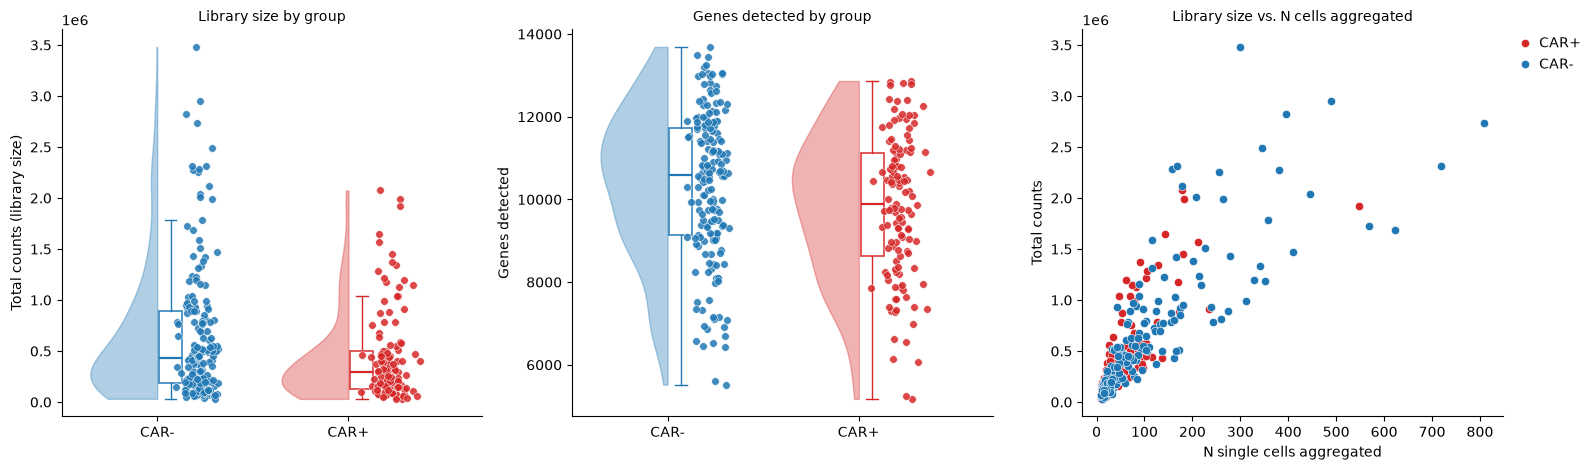

In [5]:
pb_bulk.obs["total_counts"] = np.asarray(pb_bulk.X.sum(axis=1)).ravel()
pb_bulk.obs["n_genes_detected"] = np.asarray((pb_bulk.X > 0).sum(axis=1)).ravel()

display(pb_bulk.obs.groupby("CAR")[["total_counts", "n_genes_detected", "n_cells"]].mean().round(1))


def raincloud(ax, values_by_group, positions, palette, violin_width=0.7, box_width=0.12, jitter_spread=0.05, seed=0):
    """Half-violin + boxplot + jittered raw points per group -- a lightweight raincloud plot."""
    rng = np.random.default_rng(seed)
    for pos, (group, vals) in zip(positions, values_by_group.items()):
        vals = np.asarray(vals)
        color = palette[group]

        vp = ax.violinplot([vals], positions=[pos], widths=violin_width, showextrema=False)
        body = vp["bodies"][0]
        verts = body.get_paths()[0].vertices
        verts[:, 0] = np.clip(verts[:, 0], -np.inf, pos)  # keep only the left half -> half-violin "cloud"
        body.set_facecolor(color); body.set_edgecolor(color); body.set_alpha(0.35)

        ax.boxplot(
            [vals], positions=[pos + 0.07], widths=box_width, showfliers=False, patch_artist=True,
            boxprops=dict(facecolor="white", edgecolor=color, linewidth=1.2, alpha=0.9),
            medianprops=dict(color=color, linewidth=1.6),
            whiskerprops=dict(color=color), capprops=dict(color=color),
        )

        x_jit = pos + 0.22 + rng.normal(0, jitter_spread, len(vals))
        ax.scatter(x_jit, vals, color=color, s=30, alpha=0.85, edgecolors="white", linewidths=0.4, zorder=3)


fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
car_order = ["CAR-", "CAR+"]
positions = [0, 1]

for ax, col, title, ylabel in [
    (axes[0], "total_counts", "Library size by group", "Total counts (library size)"),
    (axes[1], "n_genes_detected", "Genes detected by group", "Genes detected"),
]:
    values_by_group = {cat: pb_bulk.obs.loc[pb_bulk.obs["CAR"] == cat, col] for cat in car_order}
    raincloud(ax, values_by_group, positions, CAR_PALETTE)
    ax.set_xticks(positions); ax.set_xticklabels(car_order)
    ax.set_xlim(-0.5, 1.7)
    ax.set_ylabel(ylabel); ax.set_title(title, fontsize=10)

for cat, color in CAR_PALETTE.items():
    sub = pb_bulk.obs[pb_bulk.obs["CAR"] == cat]
    axes[2].scatter(sub["n_cells"], sub["total_counts"], c=color, label=cat, s=35, edgecolors="white", linewidths=0.4)
axes[2].set_xlabel("N single cells aggregated"); axes[2].set_ylabel("Total counts")
axes[2].set_title("Library size vs. N cells aggregated", fontsize=10)
axes[2].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))

plt.tight_layout()
plt.show()


CAR+ pseudobulk samples are built from fewer constituent single cells on average (CAR+ cells are rarer than CAR- in most infusion products), which is reflected directly in lower library sizes &mdash; this is expected from summed pseudobulk and is corrected for by DESeq2's internal size-factor normalization, not by further filtering here.

Next we drop lowly-expressed genes before fitting DESeq2 (standard practice: low-count genes contribute mostly noise and slow down dispersion estimation).


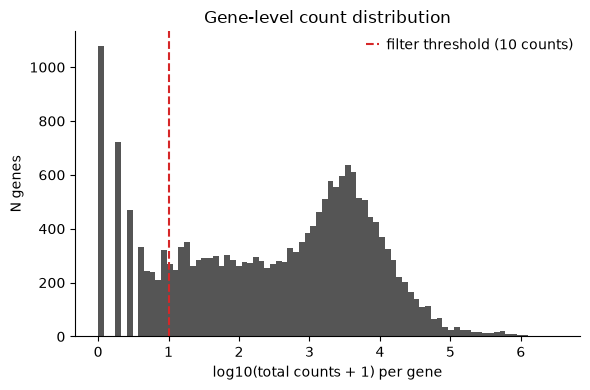

Genes before filtering: 19,522
Genes passing filter (sum>=10 counts & detected in >=20% of samples): 12,348


In [6]:
gene_sum = np.asarray(pb_bulk.X.sum(axis=0)).ravel()
gene_nsamples = np.asarray((pb_bulk.X > 0).sum(axis=0)).ravel()
keep_genes = (gene_sum >= 10) & (gene_nsamples >= 0.2 * pb_bulk.n_obs)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(np.log10(gene_sum + 1), bins=80, color="#555555")
ax.axvline(np.log10(10), color="#D62728", ls="--", label="filter threshold (10 counts)")
ax.set_xlabel("log10(total counts + 1) per gene"); ax.set_ylabel("N genes")
ax.set_title("Gene-level count distribution")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Genes before filtering: {pb_bulk.n_vars:,}")
print(f"Genes passing filter (sum>=10 counts & detected in >=20% of samples): {keep_genes.sum():,}")

pb_bulk_filt = pb_bulk[:, keep_genes].copy()


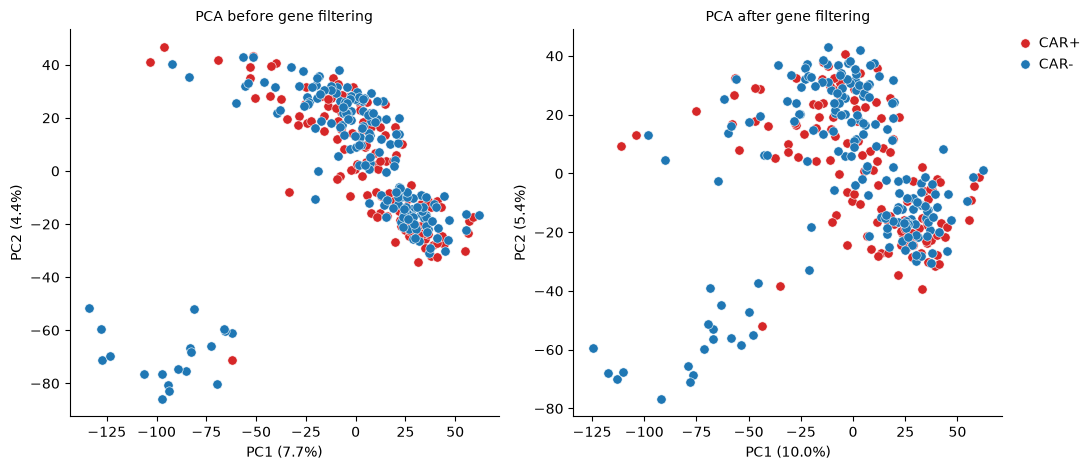

In [7]:
def quick_pca(adata_obj, title, ax):
    tmp = adata_obj.copy()
    sc.pp.normalize_total(tmp, target_sum=1e6)
    sc.pp.log1p(tmp)
    sc.pp.scale(tmp, max_value=10)
    sc.tl.pca(tmp, n_comps=10)
    var_ratio = tmp.uns["pca"]["variance_ratio"]
    for cat, color in CAR_PALETTE.items():
        m = (tmp.obs["CAR"] == cat).values
        ax.scatter(tmp.obsm["X_pca"][m, 0], tmp.obsm["X_pca"][m, 1], c=color, label=cat, s=45, edgecolors="white", linewidths=0.4)
    ax.set_xlabel(f"PC1 ({var_ratio[0]*100:.1f}%)"); ax.set_ylabel(f"PC2 ({var_ratio[1]*100:.1f}%)")
    ax.set_title(title, fontsize=10)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
quick_pca(pb_bulk, "PCA before gene filtering", axes[0])
quick_pca(pb_bulk_filt, "PCA after gene filtering", axes[1])
axes[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()


Gene filtering removes noise without disturbing the overall sample structure, as expected. As in the Section 1b UMAP, PC1/PC2 here are dominated by cell-type identity rather than CAR status (each `pb_bulk` sample is one donor x cell type x CAR combination, spanning 9 cell types) &mdash; which is exactly why Section 3 subsets `pb_bulk` into one cell type at a time rather than relying on PCA-visible separation between CAR+ and CAR- samples across the whole mixture. We proceed to Section 3 with `pb_bulk` (gene filtering will be redone per cell-type subset there, since the relevant sample size differs from one cell type to the next).

## 3. Differential expression with `pydeseq2`, per cell type

We now ask how CAR transduction affects two specific, abundant cell types: **Cycling CD4** and **Cycling CD8**. Rather than pooling cell types into one model (which would only estimate an average effect shared across cell types) or adding `cell_type_in_paper` as a covariate in one shared model (which would still report a single, pooled CAR coefficient), we subset `pb_bulk` to one cell type at a time and fit an independent `~donor_id + CAR` model within each subset. Within a single cell type there is no cell-type-composition confound to worry about &mdash; every sample literally *is* that cell type &mdash; so this is the more direct way to answer "how does CAR transduction affect Cycling CD4 specifically?" and "...Cycling CD8 specifically?" as two separate questions, and then compare the answers.

Each subset gets its own gene filter (the genes worth testing depend on that subset's sample size, not on `pb_bulk` as a whole) before DESeq2.

In [8]:
def deseq2_within_celltype(pb_bulk, cell_type, gene_symbols, min_gene_count=10, min_sample_frac=0.2):
    """Subset pb_bulk to one cell type and fit ~donor_id + CAR within it."""
    sub = pb_bulk[pb_bulk.obs["cell_type_in_paper"] == cell_type].copy()

    gene_sum = np.asarray(sub.X.sum(axis=0)).ravel()
    gene_nsamples = np.asarray((sub.X > 0).sum(axis=0)).ravel()
    keep_genes = (gene_sum >= min_gene_count) & (gene_nsamples >= min_sample_frac * sub.n_obs)
    sub_filt = sub[:, keep_genes].copy()

    counts_df = pd.DataFrame(sub_filt.X, index=sub_filt.obs_names, columns=sub_filt.var_names).astype(int)
    meta_df = sub_filt.obs[["donor_id", "CAR"]].copy()
    # re-derive categories from this subset only -- pb_bulk's donor_id category dtype
    # carries all 24 donor levels, most of which aren't present once we subset to one
    # cell type, and unused levels would make the design matrix rank-deficient.
    meta_df["donor_id"] = meta_df["donor_id"].astype(str).astype("category")
    meta_df["CAR"] = meta_df["CAR"].astype(str).astype("category")

    dds = DeseqDataSet(
        counts=counts_df, metadata=meta_df, design="~donor_id + CAR",
        ref_level=["CAR", "CAR-"], refit_cooks=True, quiet=True,
    )
    dds.deseq2()
    stat = DeseqStats(dds, contrast=["CAR", "CAR+", "CAR-"], quiet=True)
    stat.summary()
    res = stat.results_df.copy()
    res["gene_symbol"] = gene_symbols.reindex(res.index)
    res = res.dropna(subset=["padj"])
    return sub, sub_filt, res


gene_symbols = pb_full.var["feature_name"]
LFC_THRESHOLD = 0.3  # "biologically large" effect size used in volcano/MA plots and the top-genes table below

pb_cd4cyc, pb_cd4cyc_filt, res_cd4cyc = deseq2_within_celltype(pb_bulk, "Cycling CD4", gene_symbols)
pb_cd8cyc, pb_cd8cyc_filt, res_cd8cyc = deseq2_within_celltype(pb_bulk, "Cycling CD8", gene_symbols)

summary_tbl = pd.DataFrame({
    "n_samples": [pb_cd4cyc.n_obs, pb_cd8cyc.n_obs],
    "n_donors": [pb_cd4cyc.obs["donor_id"].nunique(), pb_cd8cyc.obs["donor_id"].nunique()],
    "genes_tested": [len(res_cd4cyc), len(res_cd8cyc)],
    "significant_padj<0.05": [(res_cd4cyc["padj"] < 0.05).sum(), (res_cd8cyc["padj"] < 0.05).sum()],
    f"significant_&_|log2FC|>{LFC_THRESHOLD}": [
        ((res_cd4cyc["padj"] < 0.05) & (res_cd4cyc["log2FoldChange"].abs() > LFC_THRESHOLD)).sum(),
        ((res_cd8cyc["padj"] < 0.05) & (res_cd8cyc["log2FoldChange"].abs() > LFC_THRESHOLD)).sum(),
    ],
}, index=["Cycling CD4", "Cycling CD8"])
summary_tbl


,n_samples,n_donors,genes_tested,significant_padj<0.05,significant_&_|log2FC|>0.3
Cycling CD4,42,22,2063,49,7
Cycling CD8,42,23,7361,100,47


### Comparing the CAR effect between Cycling CD4 and Cycling CD8

For genes tested in both models, we compare their CAR+ vs CAR- log2 fold changes directly: do the two cell types respond to CAR transduction in the same way, or differently?

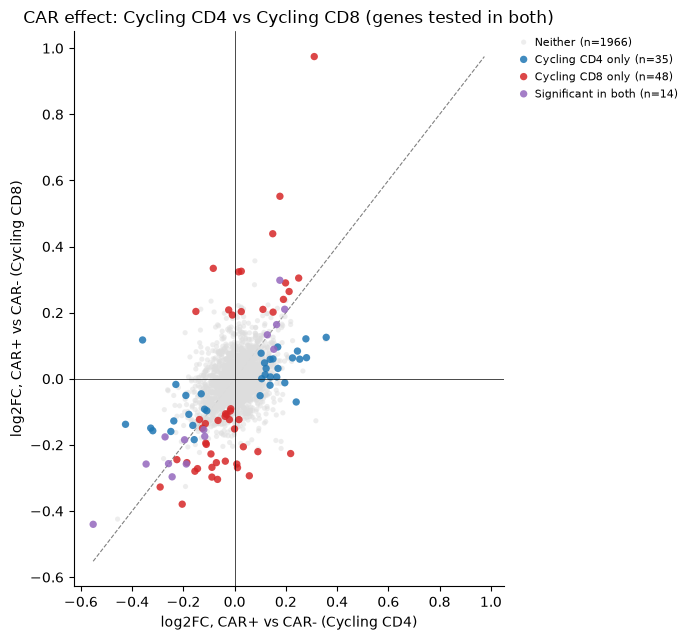

Genes tested in both models: 2,063
Significant (padj<0.05) in Cycling CD4 only: 35
Significant (padj<0.05) in Cycling CD8 only: 86
Significant in both: 14
log2FC correlation (genes tested in both): 0.43


In [9]:
both = pd.merge(
    res_cd4cyc[["log2FoldChange", "padj", "gene_symbol"]].rename(columns={"log2FoldChange": "lfc_cd4", "padj": "padj_cd4"}),
    res_cd8cyc[["log2FoldChange", "padj"]].rename(columns={"log2FoldChange": "lfc_cd8", "padj": "padj_cd8"}),
    left_index=True, right_index=True, how="inner",
)
sig_cd4 = set(res_cd4cyc[res_cd4cyc["padj"] < 0.05].index)
sig_cd8 = set(res_cd8cyc[res_cd8cyc["padj"] < 0.05].index)

def categorize(gene_id):
    in4, in8 = gene_id in sig_cd4, gene_id in sig_cd8
    if in4 and in8:
        return "Significant in both"
    if in4:
        return "Cycling CD4 only"
    if in8:
        return "Cycling CD8 only"
    return "Neither"

both["category"] = both.index.map(categorize)
cat_palette = {"Significant in both": "#9467BD", "Cycling CD4 only": "#1F77B4", "Cycling CD8 only": "#D62728", "Neither": "#DDDDDD"}
cat_order = ["Neither", "Cycling CD4 only", "Cycling CD8 only", "Significant in both"]

fig, ax = plt.subplots(figsize=(7, 6.5))
for cat in cat_order:
    sub = both[both["category"] == cat]
    ax.scatter(sub["lfc_cd4"], sub["lfc_cd8"], s=14 if cat == "Neither" else 28, c=cat_palette[cat],
               label=f"{cat} (n={len(sub)})", alpha=0.5 if cat == "Neither" else 0.85, edgecolors="none")
lims = [both[["lfc_cd4", "lfc_cd8"]].min().min(), both[["lfc_cd4", "lfc_cd8"]].max().max()]
ax.plot(lims, lims, ls="--", c="gray", lw=0.8, zorder=0)
ax.axhline(0, c="black", lw=0.5); ax.axvline(0, c="black", lw=0.5)
ax.set_xlabel("log2FC, CAR+ vs CAR- (Cycling CD4)"); ax.set_ylabel("log2FC, CAR+ vs CAR- (Cycling CD8)")
ax.set_title("CAR effect: Cycling CD4 vs Cycling CD8 (genes tested in both)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8)
plt.tight_layout()
plt.show()

print(f"Genes tested in both models: {len(both):,}")
print(f"Significant (padj<0.05) in Cycling CD4 only: {len(sig_cd4 - sig_cd8):,}")
print(f"Significant (padj<0.05) in Cycling CD8 only: {len(sig_cd8 - sig_cd4):,}")
print(f"Significant in both: {len(sig_cd4 & sig_cd8):,}")
print(f"log2FC correlation (genes tested in both): {both['lfc_cd4'].corr(both['lfc_cd8']):.2f}")


### From here on: focusing on Cycling CD8

The rest of this notebook (volcano/MA/heatmap below, then Sections 4-5) drills into the **Cycling CD8** contrast specifically. To reuse the existing plotting code with minimal changes, `res`, `pb_bulk`, and `pb_bulk_filt` are rebound below to the Cycling CD8 objects -- they now refer to the single-cell-type subset, not the 9-cell-type object from Sections 1-2.

In [10]:
res = res_cd8cyc.copy()
pb_bulk = pb_cd8cyc
pb_bulk_filt = pb_cd8cyc_filt

print(f"Cycling CD8: {pb_bulk.n_obs} samples ({pb_bulk.obs['CAR'].value_counts().to_dict()}), "
      f"{pb_bulk.obs['donor_id'].nunique()} donors")
print(f"Genes tested: {len(res):,}")
print(f"Significant (padj<0.05): {(res['padj'] < 0.05).sum():,}")
print(f"Significant & |log2FC|>{LFC_THRESHOLD}: {((res['padj'] < 0.05) & (res['log2FoldChange'].abs() > LFC_THRESHOLD)).sum():,}")
res.sort_values("padj").head(10)


Cycling CD8: 42 samples ({'CAR-': 23, 'CAR+': 19}), 23 donors
Genes tested: 7,361
Significant (padj<0.05): 100
Significant & |log2FC|>0.3: 47


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_symbol
ENSG00000019582,2462.836711,-0.249279,0.036058,-6.913305,4.734917e-12,3.485372e-08,CD74
ENSG00000117632,1051.331541,-0.184502,0.027372,-6.740628,1.577039e-11,5.804291e-08,STMN1
ENSG00000256039,170.812096,-0.417590,0.063170,-6.610597,3.827729e-11,9.391970e-08,LINC02446
ENSG00000113088,38.851382,-0.891757,0.140752,-6.335676,2.363031e-10,4.348567e-07,GZMK
ENSG00000166710,7524.385918,-0.198397,0.032410,-6.121407,9.275278e-10,1.365506e-06,B2M
ENSG00000185088,240.496568,-0.293408,0.048565,-6.041495,1.526932e-09,1.873291e-06,RPS27L
ENSG00000172116,239.525887,-0.306282,0.053284,-5.748052,9.027727e-09,9.493300e-06,CD8B
ENSG00000080822,307.678758,-0.257735,0.045477,-5.667365,1.450103e-08,1.334276e-05,CLDND1
ENSG00000120949,19.665115,0.613084,0.108726,5.638803,1.712360e-08,1.400520e-05,TNFRSF8
ENSG00000092010,419.305090,-0.174142,0.030994,-5.618535,1.925835e-08,1.417607e-05,PSME1


### Volcano plot


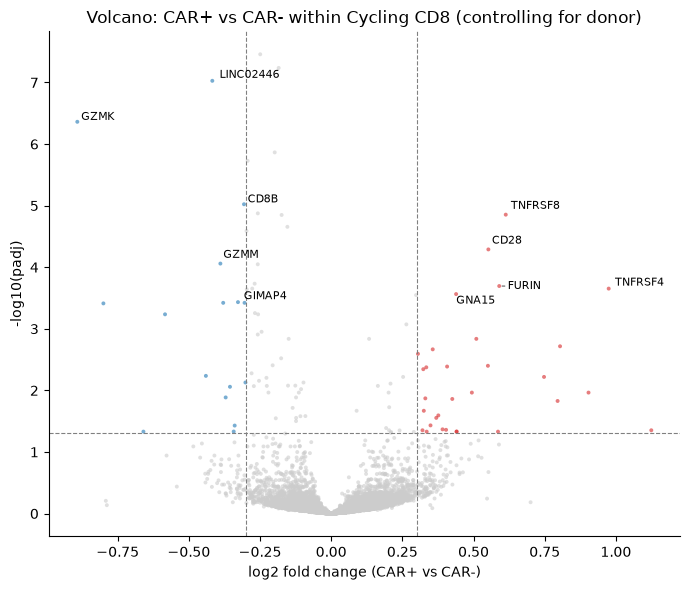

In [11]:
sig = res[(res["padj"] < 0.05) & (res["log2FoldChange"].abs() > LFC_THRESHOLD)]
res["neglog10padj"] = -np.log10(res["padj"].clip(lower=1e-300))
colors = np.where((res["padj"] < 0.05) & (res["log2FoldChange"] > LFC_THRESHOLD), CAR_PALETTE["CAR+"],
          np.where((res["padj"] < 0.05) & (res["log2FoldChange"] < -LFC_THRESHOLD), CAR_PALETTE["CAR-"], "#CCCCCC"))

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(res["log2FoldChange"], res["neglog10padj"], c=colors, s=8, alpha=0.6, edgecolors="none")
ax.axvline(LFC_THRESHOLD, ls="--", c="gray", lw=0.8); ax.axvline(-LFC_THRESHOLD, ls="--", c="gray", lw=0.8)
ax.axhline(-np.log10(0.05), ls="--", c="gray", lw=0.8)
ax.set_xlabel("log2 fold change (CAR+ vs CAR-)"); ax.set_ylabel("-log10(padj)")
ax.set_title("Volcano: CAR+ vs CAR- within Cycling CD8 (controlling for donor)")

top_up = sig[sig["log2FoldChange"] > 0].sort_values("padj").head(5)
top_dn = sig[sig["log2FoldChange"] < 0].sort_values("padj").head(5)
texts = [ax.text(row["log2FoldChange"], -np.log10(max(row["padj"], 1e-300)), row["gene_symbol"], fontsize=8)
         for _, row in pd.concat([top_up, top_dn]).iterrows()]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="black", lw=0.5))
plt.tight_layout()
plt.show()


### MA plot


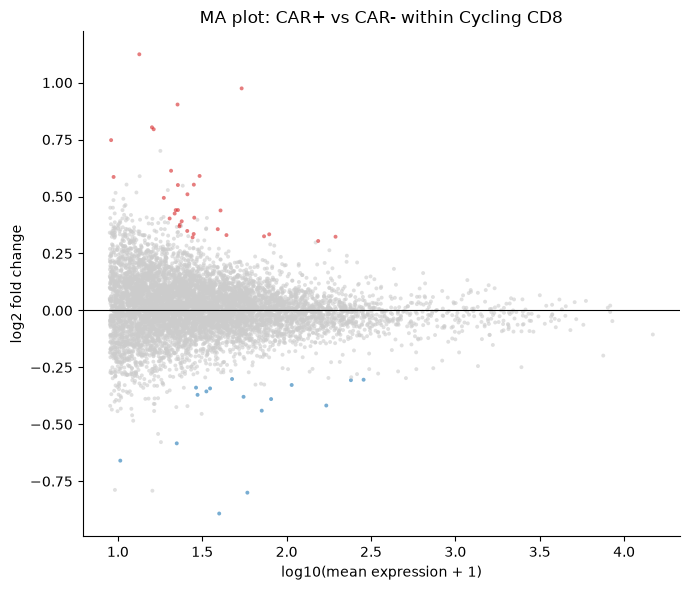

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(np.log10(res["baseMean"] + 1), res["log2FoldChange"], c=colors, s=8, alpha=0.6, edgecolors="none")
ax.axhline(0, c="black", lw=0.8)
ax.set_xlabel("log10(mean expression + 1)"); ax.set_ylabel("log2 fold change")
ax.set_title("MA plot: CAR+ vs CAR- within Cycling CD8")
plt.tight_layout()
plt.show()


### Heatmap of the top 30 differentially expressed genes (clustered, with column annotations)

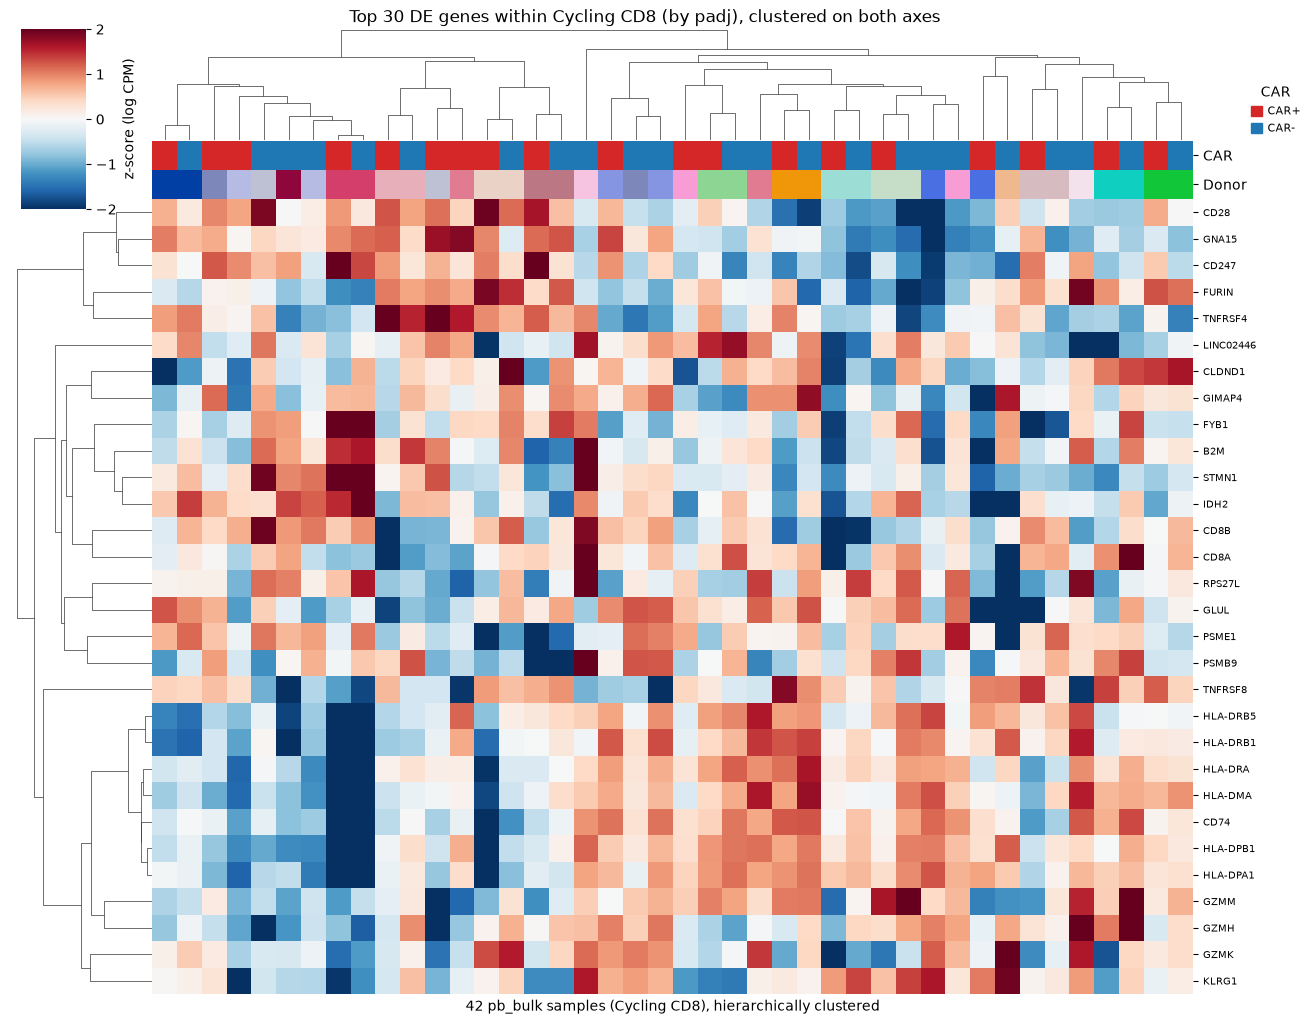

In [13]:
top_genes = res.sort_values("padj").head(30).index.tolist()
gene_labels = [gene_symbols.get(g, g) for g in top_genes]

bulk_norm = pb_bulk.copy()
sc.pp.normalize_total(bulk_norm, target_sum=1e6)
sc.pp.log1p(bulk_norm)

mat = bulk_norm[:, top_genes].X
mat_z = (mat - mat.mean(axis=0)) / mat.std(axis=0)
mat_z_df = pd.DataFrame(mat_z, index=bulk_norm.obs_names, columns=gene_labels)

# Column annotations: CAR status (the contrast) and donor (to check whether
# donor identity, rather than CAR status, is what's really driving any clusters).
col_colors = pd.DataFrame({
    "CAR": bulk_norm.obs["CAR"].map(CAR_PALETTE).values,
    "Donor": bulk_norm.obs["donor_id"].map(donor_palette).values,
}, index=bulk_norm.obs_names)

# clustermap hierarchically clusters both axes (average linkage, correlation
# distance) and draws a dendrogram on each; transposing so genes are rows
# puts the requested gene dendrogram on the left.
g = sns.clustermap(
    mat_z_df.T, metric="correlation", method="average",
    col_colors=col_colors, cmap="RdBu_r", vmin=-2, vmax=2,
    figsize=(13, 10), dendrogram_ratio=(0.12, 0.12),
    cbar_kws={"label": "z-score (log CPM)"}, xticklabels=False,
)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=7)
g.ax_heatmap.set_xlabel(f"{mat_z_df.shape[0]} pb_bulk samples (Cycling CD8), hierarchically clustered")
g.ax_heatmap.set_ylabel("")

car_handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in CAR_PALETTE.values()]
g.ax_heatmap.legend(car_handles, CAR_PALETTE.keys(), title="CAR", loc="upper left",
                     bbox_to_anchor=(1.05, 1.15), fontsize=8)
g.fig.suptitle("Top 30 DE genes within Cycling CD8 (by padj), clustered on both axes", y=1.0)
plt.show()


### Top 5 up- and down-regulated genes, with full gene names

We pull full gene descriptions from [mygene.info](https://mygene.info) for readability.


In [14]:
top10 = pd.concat([top_up.assign(direction="up"), top_dn.assign(direction="down")])
full_names = []
for sym in top10["gene_symbol"]:
    try:
        r = requests.get("https://mygene.info/v3/query",
                          params={"q": f"symbol:{sym}", "species": "human", "fields": "name,symbol"}, timeout=8)
        hits = r.json().get("hits", [])
        full_names.append(hits[0]["name"] if hits else "NA")
    except Exception:
        full_names.append("NA")
top10["full_name"] = full_names

top10_display = top10[["gene_symbol", "full_name", "log2FoldChange", "padj", "direction"]].reset_index(drop=True)
top10_display


,gene_symbol,full_name,log2FoldChange,padj,direction
0,TNFRSF8,TNF receptor superfamily member 8,0.613084,1.400520e-05,up
1,CD28,CD28 molecule,0.552005,5.140212e-05,up
2,FURIN,"furin, paired basic amino acid cleaving enzyme",0.590188,2.020209e-04,up
3,TNFRSF4,TNF receptor superfamily member 4,0.974652,2.224626e-04,up
4,GNA15,G protein subunit alpha 15,0.438723,2.729324e-04,up
5,LINC02446,long intergenic non-protein coding RNA 2446,-0.417590,9.391970e-08,down
6,GZMK,granzyme K,-0.891757,4.348567e-07,down
7,CD8B,CD8 subunit beta,-0.306282,9.493300e-06,down
8,GZMM,granzyme M,-0.389263,8.727584e-05,down
9,GIMAP4,"GTPase, IMAP family member 4",-0.327443,3.690135e-04,down


## 4. Functional enrichment with `decoupler` (Cycling CD8)

We rank Cycling CD8 genes by their DESeq2 Wald statistic (CAR+ vs CAR-) and interrogate three complementary resources, all imported through `decoupler`'s `omnipath`-backed connectors:

- **4.1** Over-Representation Analysis (ORA) of the top 100 up- and top 100 down-regulated genes against **MSigDB Hallmarks**.
- **4.2** Gene Set Enrichment Analysis (GSEA) of the full ranked gene list against **PROGENy** pathway signatures.
- **4.3** Transcription factor activity via a Univariate Linear Model (ULM) against the **CollecTRI** TF-target network (sourced from `omnipath`).


In [15]:
res_ranked = res.dropna(subset=["gene_symbol"]).sort_values("stat", ascending=False).drop_duplicates("gene_symbol", keep="first")
mat = res_ranked.set_index("gene_symbol")[["stat"]].T
mat.index = ["CARpos_vs_CARneg_CyclingCD8"]
mat_neg = -mat
stat_df = res_ranked.set_index("gene_symbol")[["stat"]]

print(f"Ranked gene matrix: {mat.shape[1]} genes, contrast '{mat.index[0]}'")


Ranked gene matrix: 7361 genes, contrast 'CARpos_vs_CARneg_CyclingCD8'


### 4.1 ORA against MSigDB Hallmarks (top 100 up vs. top 100 down)


Hallmark resource: 7318 gene-set memberships across 50 hallmarks


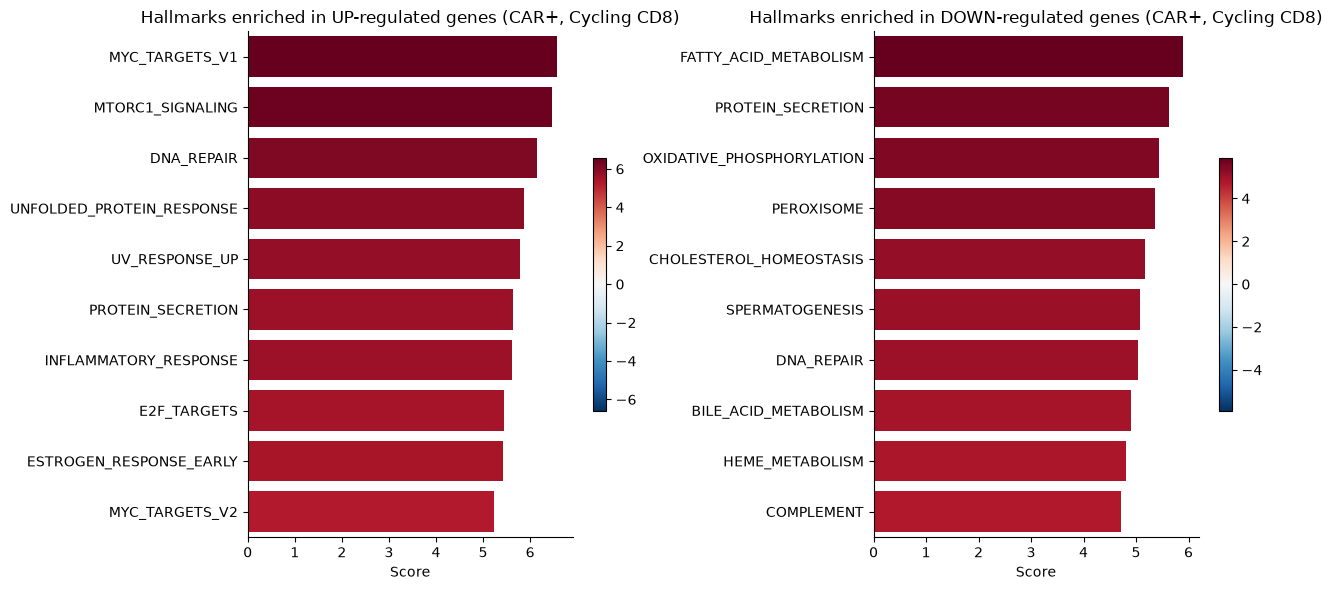

In [16]:
hallmark = dc.op.hallmark(organism="human")
print(f"Hallmark resource: {hallmark.shape[0]} gene-set memberships across {hallmark['source'].nunique()} hallmarks")

es_up, p_up = dc.mt.ora(mat, hallmark, n_up=100, n_bm=0, verbose=False)
es_dn, p_dn = dc.mt.ora(mat_neg, hallmark, n_up=100, n_bm=0, verbose=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
dc.pl.barplot(es_up, name="CARpos_vs_CARneg_CyclingCD8", top=10, ax=axes[0])
axes[0].set_title("Hallmarks enriched in UP-regulated genes (CAR+, Cycling CD8)")
dc.pl.barplot(es_dn, name="CARpos_vs_CARneg_CyclingCD8", top=10, ax=axes[1])
axes[1].set_title("Hallmarks enriched in DOWN-regulated genes (CAR+, Cycling CD8)")
plt.tight_layout()
plt.show()


### 4.2 GSEA against PROGENy pathway signatures


PROGENy resource: 6463 gene weights across 14 pathways


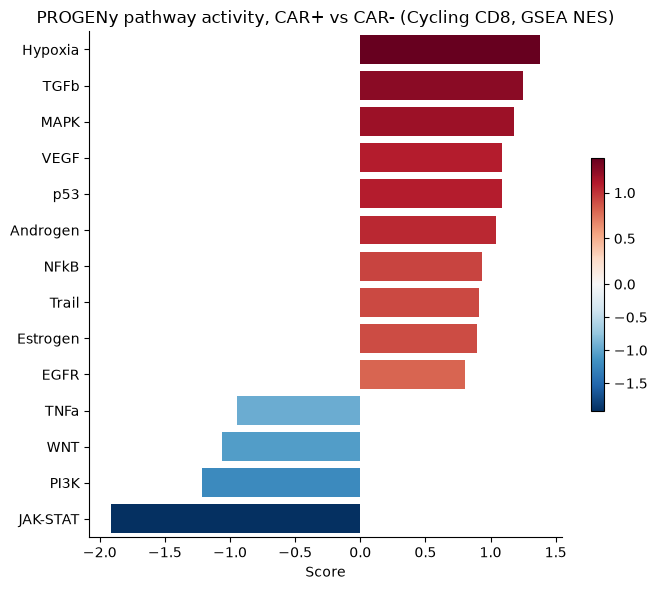

In [17]:
progeny = dc.op.progeny(organism="human", top=500)
print(f"PROGENy resource: {progeny.shape[0]} gene weights across {progeny['source'].nunique()} pathways")

es_progeny, p_progeny = dc.mt.gsea(mat, progeny, verbose=False)

fig, ax = plt.subplots(figsize=(7, 6))
dc.pl.barplot(es_progeny, name="CARpos_vs_CARneg_CyclingCD8", top=14, ax=ax)
ax.set_title("PROGENy pathway activity, CAR+ vs CAR- (Cycling CD8, GSEA NES)")
plt.tight_layout()
plt.show()


### 4.3 Transcription factor activity (ULM) using CollecTRI from `omnipath`


CollecTRI network: 42990 TF-target edges across 1185 TFs


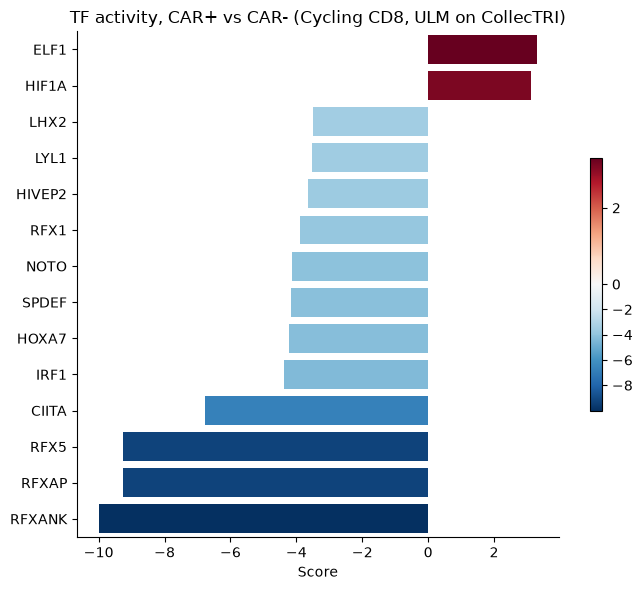

In [18]:
collectri = dc.op.collectri(organism="human")
print(f"CollecTRI network: {collectri.shape[0]} TF-target edges across {collectri['source'].nunique()} TFs")

es_tf, p_tf = dc.mt.ulm(mat, collectri, verbose=False)

fig, ax = plt.subplots(figsize=(7, 6))
dc.pl.barplot(es_tf, name="CARpos_vs_CARneg_CyclingCD8", top=14, ax=ax)
ax.set_title("TF activity, CAR+ vs CAR- (Cycling CD8, ULM on CollecTRI)")
plt.tight_layout()
plt.show()


### Leading-edge genes driving the top hallmark and the top TF

For the strongest up-regulated hallmark and the strongest down-regulated TF, we plot the GSEA-style running-enrichment curve, which marks the specific genes ("leading edge") responsible for the signal.


Top up-regulated hallmark: MYC_TARGETS_V1
Top down-regulated TF: RFXANK


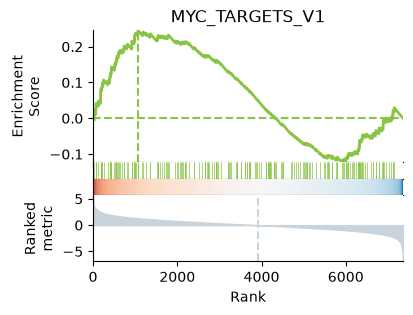

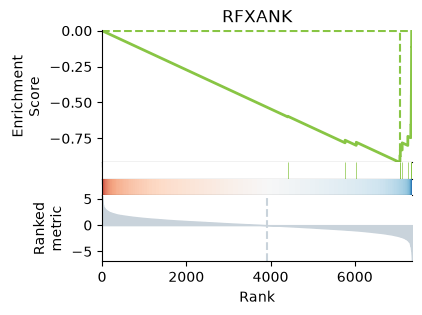


Leading-edge genes for MYC_TARGETS_V1:
 [np.str_('XPO1'), np.str_('SRM'), np.str_('SYNCRIP'), np.str_('KPNA2'), np.str_('EIF3B'), np.str_('TRIM28'), np.str_('CDC20'), np.str_('HDGF'), np.str_('TUFM'), np.str_('CAD'), np.str_('PGK1'), np.str_('GSPT1'), np.str_('EIF2S2'), np.str_('TFDP1'), np.str_('EXOSC7')]

Leading-edge genes for RFXANK targets:
 [np.str_('HLA-DRA'), np.str_('HLA-DRB5'), np.str_('HLA-DMA'), np.str_('HLA-DRB1'), np.str_('HLA-DPB1'), np.str_('HLA-DPA1'), np.str_('HLA-DQA1'), np.str_('HLA-DQB1'), np.str_('IFNG'), np.str_('HLA-E'), np.str_('HLA-DQA2')]


In [19]:
top_hallmark_up = es_up.iloc[0].idxmax()
top_tf_down = es_tf.iloc[0].idxmin()
print(f"Top up-regulated hallmark: {top_hallmark_up}")
print(f"Top down-regulated TF: {top_tf_down}")

fig1, le_hallmark = dc.pl.leading_edge(stat_df, net=hallmark, stat="stat", name=top_hallmark_up, return_fig=True)
plt.show()

fig2, le_tf = dc.pl.leading_edge(stat_df, net=collectri, stat="stat", name=top_tf_down, return_fig=True)
plt.show()

print(f"\nLeading-edge genes for {top_hallmark_up}:\n", list(le_hallmark[:15]))
print(f"\nLeading-edge genes for {top_tf_down} targets:\n", list(le_tf[:15]))


**Interpretation:** within Cycling CD8, the top up-regulated Hallmark is **MYC_TARGETS_V1** (a proliferation/biosynthesis program, leading edge dominated by ribosomal/translation and cell-cycle genes like XPO1, SRM, CDC20, EIF2S2), and the top down-regulated TF is **RFXANK**, a core subunit of the RFX complex that drives MHC class II transcription. RFXANK's leading-edge targets are almost entirely **HLA class II genes (HLA-DR/DP/DQ/DM)**, plus **IFNG** itself. So within this specific, cycling CD8 subset, CAR transduction is associated with a stronger proliferative/biosynthetic program and reduced MHC-II antigen-presentation and IFN-gamma signaling &mdash; the same qualitative direction (more proliferation, less antigen presentation) seen in earlier, broader analyses of this dataset, but now isolated to a single, well-defined cell type rather than averaged across several.


## 5. Ligand-receptor analysis with `liana+` (Cycling CD8)

We now ask a more targeted question, in line with the rest of the notebook's focus on Cycling CD8: **how does the way *other* cell types communicate with Cycling CD8 change once Cycling CD8 becomes CAR-transduced?** Autocrine signaling (a cell type talking to itself) does not answer that question, so we exclude same-cell-type pairs, and we restrict the final gained/lost analysis to **interactions where Cycling CD8 is the source or the target**.

`liana+`'s standard methods expect a `groupby` column over which to compute per-group expression statistics. We build, for each condition (CAR+ and CAR- non-exhausted), a small AnnData where each "cell" is actually one **donor's pseudobulk profile for a given cell type** &mdash; i.e. donors act as the replicate units within each cell-type group. We restrict to cell types with at least 5 donors represented in *both* conditions (so that LIANA+ has enough cell types to compute cross-talk *with* Cycling CD8), run `liana`'s `rank_aggregate` consensus method separately per condition, drop same-cell-type (source == target) pairs, and then compare the resulting interaction rankings to find ligand-receptor pairs involving Cycling CD8 that are **gained or lost** once it becomes CAR+.

In [20]:
pb_lr = pb_full.copy()
pb_lr.var_names = pb_lr.var["feature_name"].astype(str)
pb_lr.var_names_make_unique()

MIN_DONORS = 5
coverage = (
    pb_lr.obs[pb_lr.obs["group_tag"] != "other_exhausted"]
    .groupby(["cell_type_in_paper", "group_tag"], observed=True).size()
    .unstack(fill_value=0)
)
usable_cts = coverage[
    (coverage["case_CARpos_nonexhausted"] >= MIN_DONORS) & (coverage["control_CARneg_nonexhausted"] >= MIN_DONORS)
].index.tolist()
print("Cell types usable for LIANA+ (>=5 donors in both conditions):")
display(coverage.loc[usable_cts])


Cell types usable for LIANA+ (>=5 donors in both conditions):


group_tag,case_CARpos_nonexhausted,control_CARneg_nonexhausted
cell_type_in_paper,,
CD8,11,18
Cycling CD4,21,21
Cycling CD8,19,23
Exhausted CD8,16,21
Memory CD4,21,22
Naive CD8,9,17
TH17,19,20
Treg,8,16


In [21]:
FOCUS_CELLTYPE = "Cycling CD8"

liana_results = {}
for tag in ["case_CARpos_nonexhausted", "control_CARneg_nonexhausted"]:
    sub = pb_lr[(pb_lr.obs["group_tag"] == tag) & (pb_lr.obs["cell_type_in_paper"].isin(usable_cts))].copy()
    sc.pp.normalize_total(sub, target_sum=1e6)
    sc.pp.log1p(sub)
    sub.obs["cell_type_in_paper"] = sub.obs["cell_type_in_paper"].astype(str).astype("category")

    res_liana = li.mt.rank_aggregate(
        sub, groupby="cell_type_in_paper", resource_name="consensus",
        expr_prop=0.1, min_cells=MIN_DONORS, use_raw=False, n_perms=200,
        verbose=False, inplace=False, seed=0,
    )
    n_before = res_liana.shape[0]
    res_liana = res_liana[res_liana["source"] != res_liana["target"]]  # keep cross-cell-type pairs only
    n_cross = res_liana.shape[0]
    res_liana = res_liana[
        (res_liana["source"] == FOCUS_CELLTYPE) | (res_liana["target"] == FOCUS_CELLTYPE)
    ].reset_index(drop=True)  # keep only interactions involving Cycling CD8
    liana_results[tag] = res_liana
    print(f"{tag}: {n_before} ligand-receptor x cell-type-pair rows, {n_cross} after excluding same-cell-type "
          f"(autocrine) pairs, {res_liana.shape[0]} after restricting to {FOCUS_CELLTYPE} as source or target")


case_CARpos_nonexhausted: 43177 ligand-receptor x cell-type-pair rows, 37746 after excluding same-cell-type (autocrine) pairs, 10787 after restricting to Cycling CD8 as source or target


control_CARneg_nonexhausted: 48554 ligand-receptor x cell-type-pair rows, 42425 after excluding same-cell-type (autocrine) pairs, 11588 after restricting to Cycling CD8 as source or target


### Top interactions involving Cycling CD8 within the CAR+ (case) and CAR- (control) conditions

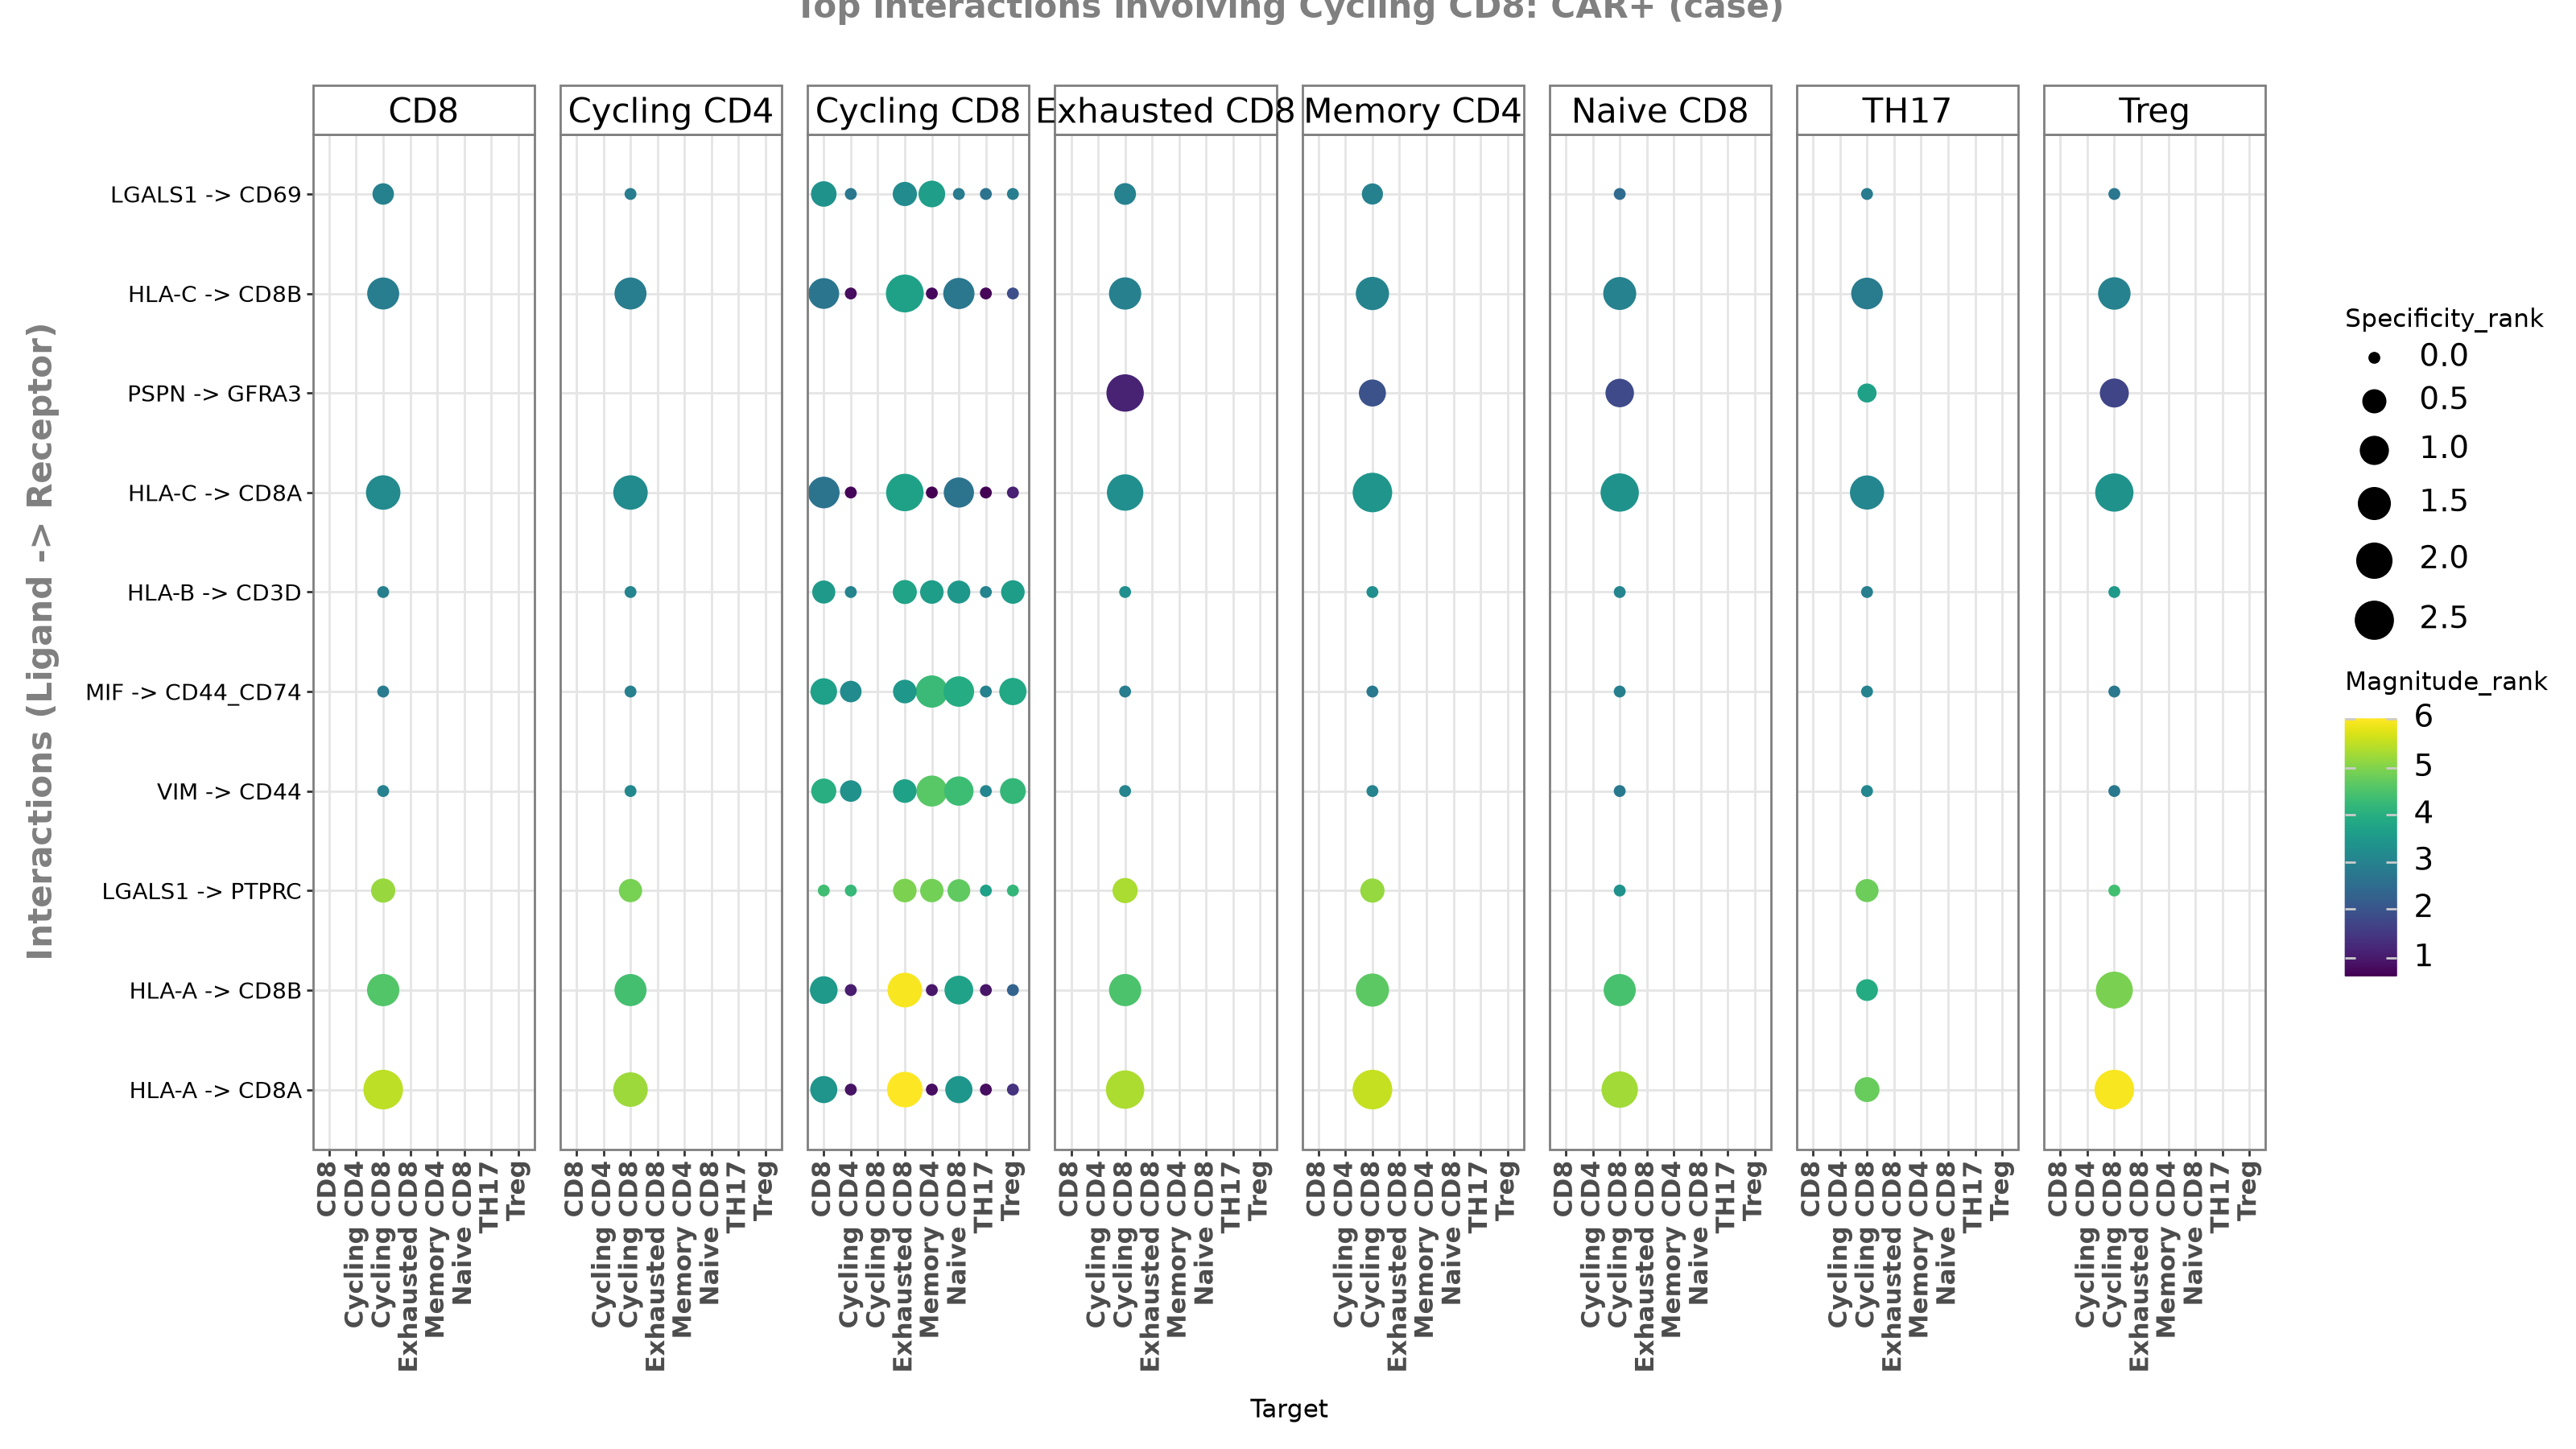

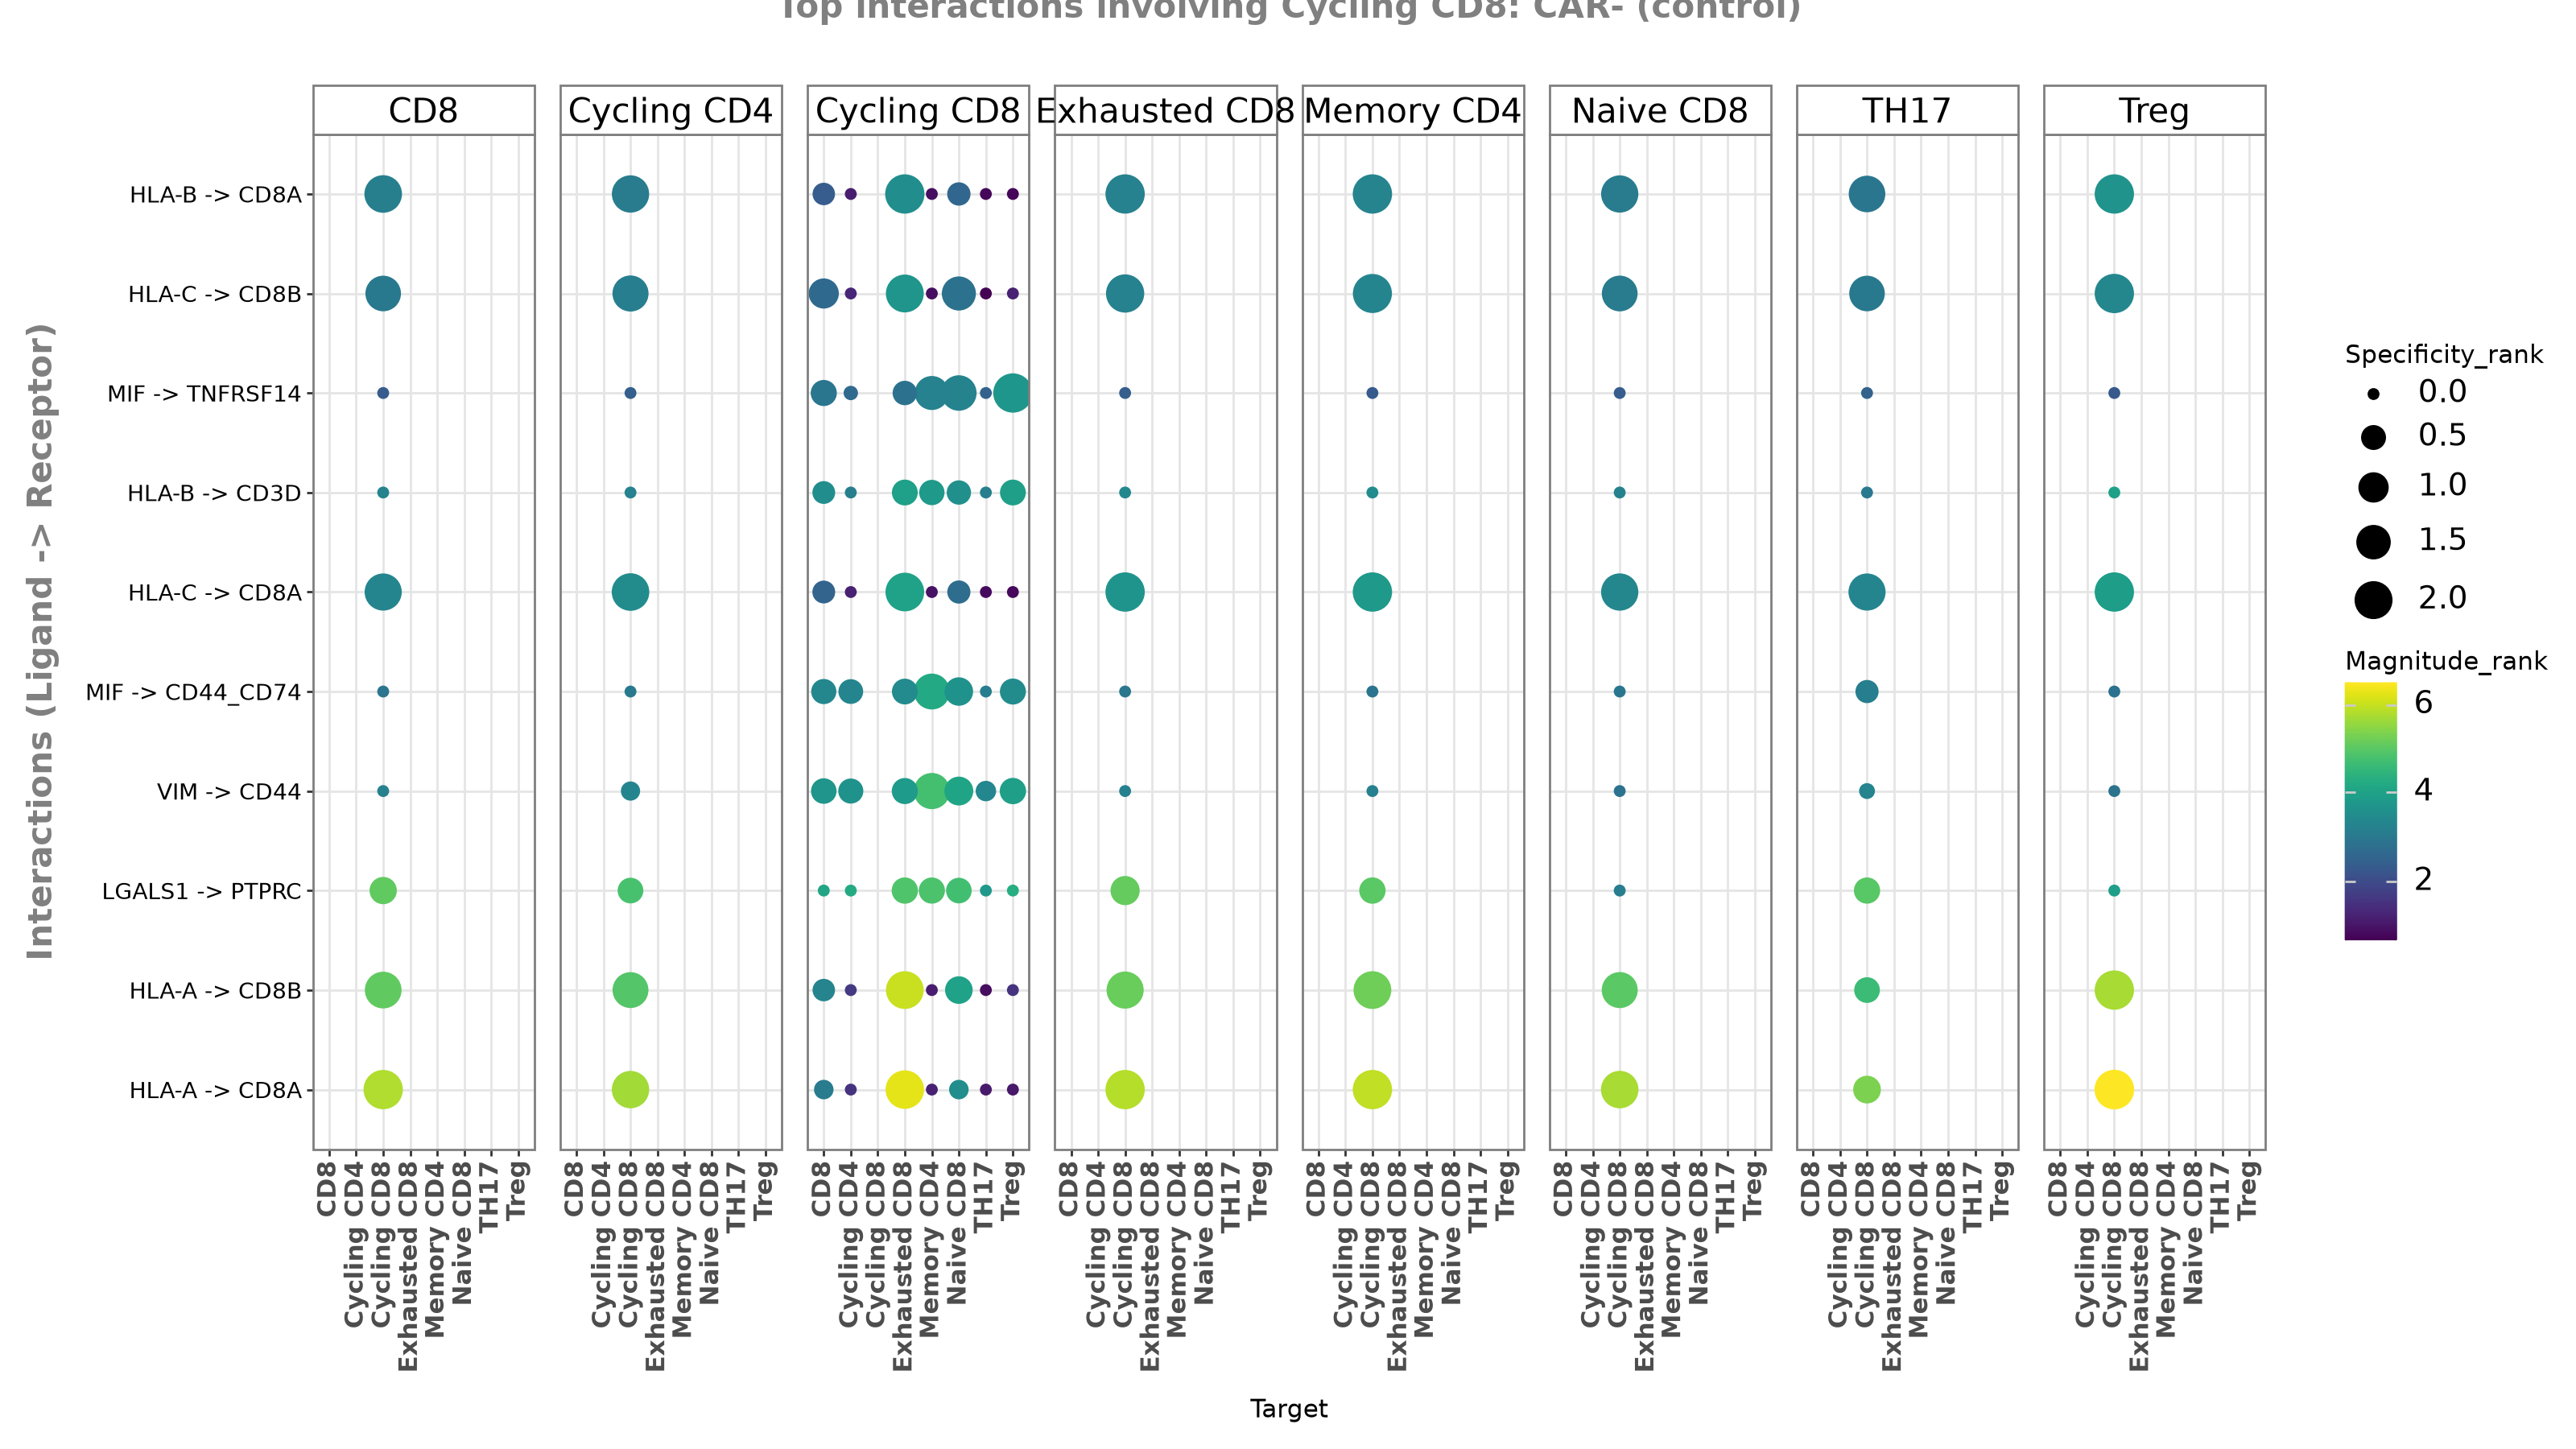

In [22]:
from IPython.display import display

for tag, title in [("case_CARpos_nonexhausted", "CAR+ (case)"), ("control_CARneg_nonexhausted", "CAR- (control)")]:
    p = li.pl.dotplot(
        liana_res=liana_results[tag], colour="magnitude_rank", size="specificity_rank",
        inverse_colour=True, inverse_size=True, top_n=10,
        orderby="magnitude_rank", orderby_ascending=True, figure_size=(16, 9),
    )
    p = p + p9.ggtitle(f"Top interactions involving {FOCUS_CELLTYPE}: {title}")
    display(p)


### Cycling CD8 interactions disrupted by CAR transduction

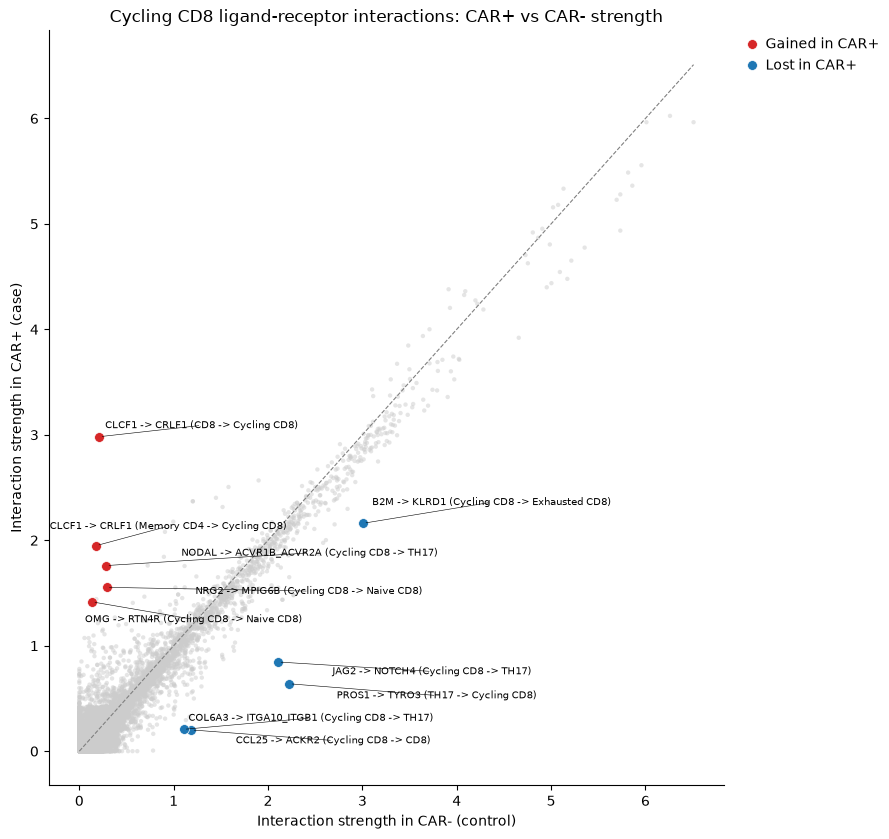

In [23]:
key_cols = ["source", "target", "ligand_complex", "receptor_complex"]
case_s = liana_results["case_CARpos_nonexhausted"][key_cols + ["magnitude_rank"]].rename(columns={"magnitude_rank": "magnitude_rank_case"})
ctrl_s = liana_results["control_CARneg_nonexhausted"][key_cols + ["magnitude_rank"]].rename(columns={"magnitude_rank": "magnitude_rank_ctrl"})
merged = pd.merge(case_s, ctrl_s, on=key_cols, how="inner")

merged["score_case"] = -np.log10(merged["magnitude_rank_case"].clip(lower=1e-12))
merged["score_ctrl"] = -np.log10(merged["magnitude_rank_ctrl"].clip(lower=1e-12))
merged["delta"] = merged["score_case"] - merged["score_ctrl"]
merged["pair_label"] = merged["ligand_complex"] + " -> " + merged["receptor_complex"] + " (" + merged["source"] + " -> " + merged["target"] + ")"

gained = merged.sort_values("delta", ascending=False).head(5)
lost = merged.sort_values("delta").head(5)

fig, ax = plt.subplots(figsize=(9, 8.5))
ax.scatter(merged["score_ctrl"], merged["score_case"], s=10, c="#CCCCCC", alpha=0.5, edgecolors="none")
ax.scatter(gained["score_ctrl"], gained["score_case"], s=50, c=CAR_PALETTE["CAR+"], label="Gained in CAR+", edgecolors="white", linewidths=0.5, zorder=3)
ax.scatter(lost["score_ctrl"], lost["score_case"], s=50, c=CAR_PALETTE["CAR-"], label="Lost in CAR+", edgecolors="white", linewidths=0.5, zorder=3)
lims = [merged[["score_ctrl", "score_case"]].min().min(), merged[["score_ctrl", "score_case"]].max().max()]
ax.plot(lims, lims, ls="--", c="gray", lw=0.8, zorder=1)
ax.set_xlabel("Interaction strength in CAR- (control)"); ax.set_ylabel("Interaction strength in CAR+ (case)")
ax.set_title(f"{FOCUS_CELLTYPE} ligand-receptor interactions: CAR+ vs CAR- strength")

texts = [ax.text(row["score_ctrl"], row["score_case"], row["pair_label"], fontsize=7)
         for _, row in pd.concat([gained, lost]).iterrows()]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="black", lw=0.4),
            expand=(1.6, 1.8), force_text=(0.6, 0.8), force_points=(0.3, 0.3))
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()


In [24]:
print(f"Top {FOCUS_CELLTYPE} interactions GAINED upon CAR transduction:")
display(gained[["pair_label", "score_ctrl", "score_case", "delta"]].reset_index(drop=True))

print(f"\nTop {FOCUS_CELLTYPE} interactions LOST upon CAR transduction:")
display(lost[["pair_label", "score_ctrl", "score_case", "delta"]].reset_index(drop=True))


Top Cycling CD8 interactions GAINED upon CAR transduction:


,pair_label,score_ctrl,score_case,delta
0,CLCF1 -> CRLF1 (CD8 -> Cycling CD8),0.213216,2.982090,2.768875
1,CLCF1 -> CRLF1 (Memory CD4 -> Cycling CD8),0.179449,1.949159,1.769710
2,NODAL -> ACVR1B_ACVR2A (Cycling CD8 -> TH17),0.285377,1.760164,1.474786
3,OMG -> RTN4R (Cycling CD8 -> Naive CD8),0.136809,1.415700,1.278891
4,NRG2 -> MPIG6B (Cycling CD8 -> Naive CD8),0.289782,1.553641,1.263859



Top Cycling CD8 interactions LOST upon CAR transduction:


,pair_label,score_ctrl,score_case,delta
0,PROS1 -> TYRO3 (TH17 -> Cycling CD8),2.227119,0.638973,-1.588146
1,JAG2 -> NOTCH4 (Cycling CD8 -> TH17),2.109109,0.845420,-1.263689
2,CCL25 -> ACKR2 (Cycling CD8 -> CD8),1.187369,0.201487,-0.985882
3,COL6A3 -> ITGA10_ITGB1 (Cycling CD8 -> TH17),1.104373,0.207067,-0.897305
4,B2M -> KLRD1 (Cycling CD8 -> Exhausted CD8),3.009520,2.161018,-0.848502


## Summary

- Pseudobulk profiles separate primarily by cell type, so we ask "how does CAR transduction affect this cell type?" as a separate `~donor_id + CAR` model fit *within* each cell type of interest, rather than pooling cell types together (which would only give a shared, averaged effect) or relying on a PCA-visible split between CAR+ and CAR- across a cell-type mixture.
- Cycling CD4 (42 samples, 22 donors) and Cycling CD8 (42 samples, 23 donors) respond differently: 2,063 genes were testable in both models, but only 14 were significant (padj<0.05) in both, vs. 35 significant in Cycling CD4 only and 86 in Cycling CD8 only (log2FC correlation across both = 0.43) &mdash; CAR transduction's transcriptional footprint is substantially cell-type-specific, with a larger, more detectable effect in Cycling CD8 (100 significant genes overall vs. 49 in Cycling CD4).
- Focusing on Cycling CD8: decoupler enrichment converges on **increased MYC-driven proliferation/biosynthesis** (top Hallmark: MYC_TARGETS_V1) and **decreased MHC class II antigen presentation / IFN-gamma signaling** (top down TF: RFXANK, with HLA-DR/DP/DQ/DM and IFNG as leading-edge targets) once a Cycling CD8 cell carries the CAR transgene.
- LIANA+ restricted to interactions involving Cycling CD8 as source or target identifies specific ligand-receptor pairs gained (e.g. CLCF1->CRLF1 from CD8/Memory CD4 into Cycling CD8) or lost (e.g. PROS1->TYRO3 from TH17 into Cycling CD8; B2M->KLRD1 from Cycling CD8 into Exhausted CD8) once Cycling CD8 becomes CAR-transduced &mdash; hypotheses for how CAR transduction rewires this specific cell type's communication with its microenvironment.

This notebook is a template: swapping `FOCUS_CELLTYPE` and the two cell types compared in Section 3 (currently Cycling CD4 vs Cycling CD8) reruns the same pipeline on a different cell-type-specific contrast.
